# Task 11: Bridging the Gap in Text-Based Emotion Detection

## Author: Senén Martínez Andreu

This notebook addresses the resolution of task 11 on emotion detection from SEMEVAL.

This challenge consists of the following subtasks:

- Track 1 (Multi-label Emotion Detection):

- Track 2 (Emotion Intensity ):

- Track 3 (Cross-lingual Emotion Detection):


Although this Task has 3 main subtasks to address, due to the limited time available to complete this challenge, I have opted to work on a single subtask — in my case, I will analyze Track 1 for multi-label emotion detection.

Each text must be classified into one or more of these emotions:

- Joy:

- Sadness

- Surprise

- Fear

- Anger

## Library Imports

In [ ]:
# Install libraries. This cell is useful for example when running the notebook in Google Colab
# Note that other dependencies like tensorflow, etc. would already be installed in this case
%%capture
%pip uninstall -y tensorflow keras tf-keras transformers ml-dtypes
%pip install -q --no-cache-dir \
  "tensorflow==2.19.0" \
  "tf-keras==2.19.0" \
  "ml-dtypes>=0.5.1,<1.0.0" \
  "transformers==4.38.2" \
  pandas plotly scikit-learn

print('Done!')

In [ ]:
# reset environment
%reset -f

# para establecer caminos al guardar y leer archivos
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import json
# for loading data and performing basic preprocessing
import pandas as pd
import numpy as np
from collections import Counter
from sklearn import preprocessing
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
# para evaluar los modelos
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score, recall_score, precision_score
from sklearn.utils.multiclass import unique_labels

#  for building plots and performing exploratory data analysis
import plotly.graph_objects as go
import plotly.figure_factory as ff
import plotly.express as px
from tqdm import tqdm

# for saving models
import pickle
import tensorflow as tf
from transformers.modeling_tf_utils import keras
from tensorflow.keras.utils import plot_model
import torch

# for visualizing models
from IPython.core.display import display

# classification algorithms, tokenizers, etc.
from transformers import DistilBertTokenizer, TFDistilBertModel, DistilBertConfig, TFDistilBertMainLayer

print('Done!')

Done!


## Data Loading

In [ ]:
url_train = "https://raw.githubusercontent.com/emotion-analysis-project/SemEval2025-Task11/main/task-dataset/semeval-2025-task11-dataset/track_a/train/eng.csv"
url_val  = "https://raw.githubusercontent.com/emotion-analysis-project/SemEval2025-Task11/main/task-dataset/semeval-2025-task11-dataset/track_a/dev/eng.csv"
url_test = "https://raw.githubusercontent.com/emotion-analysis-project/SemEval2025-Task11/main/task-dataset/semeval-2025-task11-dataset/track_a/test/eng.csv"

train = pd.read_csv(url_train)
val = pd.read_csv(url_val)
test = pd.read_csv(url_test)

## Exploratory Analysis

In [ ]:
emotions = ['joy','sadness','surprise','fear','anger']
n_train = len(train)
n_val = len(val)
n_test = len(test)


proporcion_emociones_train = train[emotions].sum()/n_train
proporcion_emociones_val = val[emotions].sum()/n_val

print(f'Proportion of emotions in the training set: \n\n {proporcion_emociones_train} \n')
print(f'Proportion of emotions in the validation set: \n\n {proporcion_emociones_val} \n')

Proporción de emociones en el conjunto de entrenamiento: 

 joy         0.243849
sadness     0.316932
surprise    0.303546
fear        0.582489
anger       0.120478
dtype: float64 

Proporción de emociones en el conjunto de validación: 

 joy         0.269565
sadness     0.295652
surprise    0.269565
fear        0.539130
anger       0.139130
dtype: float64 



## Utils

In [ ]:
# helper function to obtain input tensors for the model from text
def get_model_inputs(cfg, data):
  # obtain ids and masks for the training set
  # its not necessary convert a tensors because the output of the tokenizer is found in this format
  encodings = cfg['tokenizer'](data, truncation=True, padding='max_length', max_length=cfg['max_length'], return_tensors=cfg['framework'])


  # obtain tf-idf representation for each instance
  tfidf = cfg['vectorizer'].transform(data)
  tfidf_t = tf.convert_to_tensor(tfidf.toarray(), dtype='int32')

  # formatting the input data according to the options allowed for TF
  # the name of the input layers to build the model ('input_ids', 'attention_mask', 'tfidf')
  # are used as keys in the dictionary that represents the entry of the models
  inputs = {'input_ids': encodings['input_ids'],
            'attention_mask': encodings['attention_mask'],
            'tfidf': tfidf_t
            }

  return inputs


# helper function to make predictions with the model
def predict_model(model, cfg, data, pref='m',threshold = 0.5):
  """
  data: list of the text to predict
  pref: identificador para las columnas (labels_[pref], scores_[pref]_[class 1], etc.)
  """
  res = {}
  inputs = get_model_inputs(cfg, data)
  scores = model.predict(inputs)

  # Packing scores in a dictionary that contains labels, score of label 1, score of label 2, ... 
  # Add scores for each emotion
  for i, emotion in enumerate(emotions):
    res[f'scores_{pref}_{emotion}'] = scores[:, i]

  # Converting to binary and getting labels
  predictions_binary = (scores > threshold).astype(int)
  predicted_labels = []
  for row in predictions_binary:
    pred_emotions = [emotions[i] for i, val in enumerate(row) if val == 1]
    predicted_labels.append(', '.join(pred_emotions) if pred_emotions else 'none')

    res[f'labels_{pref}'] = predicted_labels


  # convert to dataframe ordering columns: first the label, then scores per class, classes sorted alphabetically
  res = pd.DataFrame(res, columns=sorted(list(res.keys())))
  return res


# helper function that evaluates the results of a classification
def evaluate_model(y_true, y_pred, y_score=None, pos_label='positive'):

    print('==== Classification Summary ==== ')

    # convertir predicciones string -> matriz binaria
    if isinstance(y_pred, pd.Series) and isinstance(y_pred.iloc[0], str):

        y_pred_binary = np.zeros((len(y_pred), len(emotions)))

        for i, pred_str in enumerate(y_pred):
            if pred_str != 'none':
                for emotion in pred_str.split(', '):
                    emotion = emotion.strip()

                    if emotion in emotions:
                        y_pred_binary[i, emotions.index(emotion)] = 1

        y_true = y_true.values if hasattr(y_true, 'values') else y_true
        y_pred = y_pred_binary

    # full report
    print(classification_report(
        y_true,
        y_pred,
        target_names=emotions,
        zero_division=0
    ))

    dict_classification_report = classification_report(
        y_true,
        y_pred,
        target_names=emotions,
        zero_division=0,
        output_dict=True
    )


    # coherent metrics for multi-label
    f1_macro = f1_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred, average='macro')
    precision = precision_score(y_true, y_pred, average='macro')

    # accuracy partial
    label_accuracy = (y_true == y_pred).mean()

    print(f'Label Acc  : {label_accuracy:.2%}')
    print(f'F1 Macro   : {f1_macro:.2%}')
    print(f'Recall     : {recall:.2%}')
    print(f'Precision  : {precision:.2%}')

    return dict_classification_report


def configure_model(input_ids, input_masks, input_tfidf, classifier):
    # define optimization algorithm
    optimizer = keras.optimizers.Adam(learning_rate=5e-5)

    # define loss function. It must be consistent with the expected model output (vector of num_labels elements)
    # and the format of examples (one-hot vector of num_labels components to encode categories)
    loss = keras.losses.BinaryCrossentropy(from_logits=True)

    # creating the model
    model = keras.Model(inputs=[input_ids, input_masks, input_tfidf], outputs=classifier, name='distilbert-custom')
    # compile the model, specifying other metrics to monitor
    # The metric must be appropriate for the type of problem (binary or multiclass classification)
    model.compile(optimizer=optimizer, loss=loss, metrics=['binary_accuracy'])

    return model


## Processing

In [ ]:
vectorizer = CountVectorizer(ngram_range=(1,2))
X_train = vectorizer.fit_transform(train['text'].str.lower()).toarray()
X_val = vectorizer.transform(val['text'].str.lower()).toarray()

emotions = ['joy','sadness','surprise','fear','anger']
y_train = train[emotions].values
y_val = val[emotions].values

X_train_t = torch.Tensor(X_train)
y_train_t = torch.Tensor(y_train)

X_val_t = torch.Tensor(X_val)
y_val_t = torch.Tensor(y_val)

print(f'Shape of X: {X_train.shape}')
print(f'Shape of y: {y_train.shape}')
print(f'Number of positives per emotion class:')
_ = [print(f' - {e}: {v} ({round(100*v/len(y_train))}%)') for e,v in zip(emotions, y_train.sum(axis=0))]

Shape of X: (2764, 28954)
Shape of y: (2764, 5)
Number of positives per emotion class:
 - joy: 674 (24%)
 - sadness: 876 (32%)
 - surprise: 839 (30%)
 - fear: 1610 (58%)
 - anger: 333 (12%)


In [ ]:
text_col = 'text' # Column that contain the text.
class_col = emotions  # Column of the dataframe that contain the class.


In [ ]:
def get_model_graph(cfg):
  # load the layer that represent the transformer, in this case, TFDistilbBertMainLayer
  transformer = TFDistilBertModel.from_pretrained(cfg['transformer_model_name'], return_dict=False).distilbert

  # create the placeholder for each input of the model
  # create variable that will represent id inputs for the Transformer
  input_ids = keras.layers.Input(shape=(cfg['max_length'],), name='input_ids', dtype='int32')

  # create variable that will represent mask inputs for the Transformer
  input_masks = keras.layers.Input(shape=(cfg['max_length'],), name='attention_mask', dtype='int32')

  # create variable that will represent inputs corresponding to domain-specific features.
  input_tfidf = keras.layers.Input(shape=(cfg['number_of_additional_features'],), name='tfidf', dtype='float32')

  # Indicate that TFDistilBertMainLayer is called with input_ids and input_mask and capture the output that contain the embeddings of each token
  # There are several criteria (e.g. https://arxiv.org/pdf/1908.10084.pdf) on which components to use as features,
  # in this case, we will take the embedding of the beginning of the sentence [CLS]
  transformer_output = transformer(input_ids, attention_mask=input_masks)

  # extract the embedding [CLS]
  # the transformation will depend on the output type of the Transformer used, in this case TFDistilBertMainLayer
  # whose output is a tuple of a single element, containing an array of dimensions
  # (number_of_instances, number_of_tokens, embedding_dimension), donde el token 0 corresponde al CLS.
  transformes_cls_embedding = keras.layers.Lambda(lambda seq: seq[0][:,0,:], name='lambda')(transformer_output)

  # concatenate embedding of token [CLS]
  features = keras.layers.concatenate([transformes_cls_embedding, input_tfidf], name='concatenate')

  # set some model hyperparameters
  initializer_range = 0.02
  hiden_units = 768
  seq_classif_dropout=0.2
  initializer = keras.initializers.TruncatedNormal(stddev=initializer_range)

  # create pre_classifier establish its entry with features concatenated
  pre_classifier = keras.layers.Dense(hiden_units, kernel_initializer=initializer, activation='relu', name='pre_classifier')(features)

  # create dropout layer
  dropout_layer = keras.layers.Dropout(rate=seq_classif_dropout, name='dropout')(pre_classifier)

  # create classifier
  classifier = keras.layers.Dense(cfg['num_labels'], kernel_initializer=initializer, name='classifier')(dropout_layer)

  return input_ids, input_masks, input_tfidf, classifier

print('Done!')

Done!


## Experiment 1: Baseline

### Configuration

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_transform.bias', 'vocab_projector.bias', 'vocab_transform.weight', 'vocab_layer_norm.bias', 'vocab_layer_norm.weight']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a Bert

Model: "distilbert-custom"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, 256)]                0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, 256)]                0         []                            
 )                                                                                                
                                                                                                  
 distilbert (TFDistilBertMa  ((None, 256, 768),           6636288   ['input_ids[0][0]',           
 inLayer)                    )                            0          'attention_mask[0][0]']      
                                                                                  

/usr/local/lib/python3.12/dist-packages/tf_keras/src/initializers/initializers.py:121: UserWarning: The initializer TruncatedNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


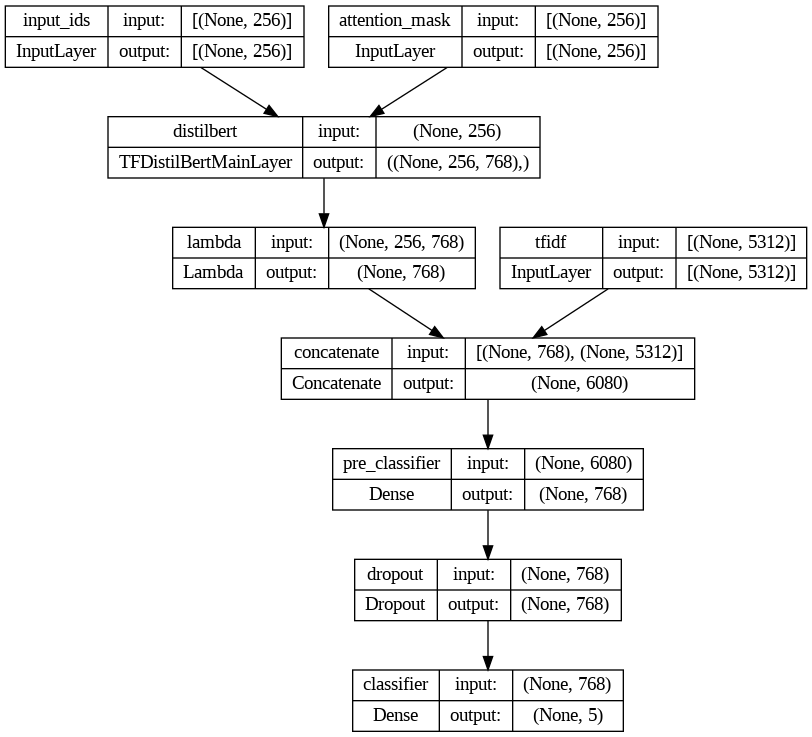

Done!


In [ ]:
# ==========================================================
# GENERAL CONFIGURATION
# ==========================================================

cfg = {}

cfg['framework'] = 'tf'
cfg['max_length'] = 256
cfg['transformer_model_name'] = 'distilbert-base-uncased'
cfg['num_labels'] = 5

# ==========================================================
# TOKENIZER
# ==========================================================

cfg['tokenizer'] = DistilBertTokenizer.from_pretrained(
    cfg['transformer_model_name']
)

# ==========================================================
# TF-IDF VECTORIZER
# ==========================================================

cfg['vectorizer'] = TfidfVectorizer(
    stop_words='english',
    max_features=10000
)

# train vectorizer
cfg['vectorizer'].fit(train[text_col].to_list())

# number of features TF-IDF
cfg['number_of_additional_features'] = len(
    cfg['vectorizer'].get_feature_names_out()
)

# save vectorizer
with open('vectorizer_reviews.pkl', 'wb') as f:
    pickle.dump(cfg['vectorizer'], f)

# ==========================================================
# LABEL BINARIZER
# ==========================================================

cfg['label_binarizer'] = preprocessing.MultiLabelBinarizer()

# train label binarizer
cfg['label_binarizer'].fit(train[class_col])

# save label binarizer
with open('label_binarizer_reviews.pkl', 'wb') as f:
    pickle.dump(cfg['label_binarizer'], f)

# ==========================================================
# MODEL
# ==========================================================

input_ids, input_masks, input_tfidf, classifier = get_model_graph(cfg)

model = configure_model(input_ids,input_masks,input_tfidf,classifier)

# print architecture
model.summary()

# visualize architecture
model_image = plot_model(model,show_shapes=True,show_layer_names=True)

display(model_image)

# ==========================================================
# LABELS
# ==========================================================

# get labels
train_labels = train[emotions].values.astype('float32')
val_labels = val[emotions].values.astype('float32')

# transform to tensor
train_labels_t = tf.convert_to_tensor(train_labels)
val_labels_t = tf.convert_to_tensor(val_labels)

# ==========================================================
# INPUTS 
# ==========================================================

train_inputs = get_model_inputs(cfg,train[text_col].to_list())

val_inputs = get_model_inputs(cfg,val[text_col].to_list())

print('Done!')

### Training



In [ ]:
# config
cfg['checkpoints_dir'] = 'checkpoints'  # directory where checkpoints will be saved when training the model
cfg['model_name'] = 'experimento1'  # id to save checkpoints 
cfg['trained_model_name'] = os.path.join(cfg['checkpoints_dir'], cfg['model_name'])

epochs_max = 3
epochs_to_save = 1 # if epochs_max % epochs_to_save !=0 extra iterations might occur
batch_size = 64

# fine-tunning
for epoch_current in range(0, epochs_max, epochs_to_save):
    epoch_from = epoch_current +1
    epoch_to = epoch_current + epochs_to_save
    print(f'Training model, epochs {epoch_from} - {epoch_to}')

    # train the model. Optionally, validation data can be supplied => validation_data=(val_inputs,val_blabels_t)
    model.fit(train_inputs, y=train_labels_t, initial_epoch=epoch_current, epochs=epoch_to, batch_size=batch_size, validation_data=(val_inputs,val_labels_t))

    model.save_weights(cfg['trained_model_name'], save_format="tf")

print('Done!')

Training model, epochs 1 - 1
44/44 [==============================] - 118s 2s/step - loss: 0.5537 - binary_accuracy: 0.7156 - val_loss: 0.4796 - val_binary_accuracy: 0.7565
Training model, epochs 2 - 2
Epoch 2/2
44/44 [==============================] - 75s 2s/step - loss: 0.4072 - binary_accuracy: 0.8108 - val_loss: 0.4182 - val_binary_accuracy: 0.8104
Training model, epochs 3 - 3
Epoch 3/3
44/44 [==============================] - 75s 2s/step - loss: 0.2983 - binary_accuracy: 0.8743 - val_loss: 0.4128 - val_binary_accuracy: 0.8070
Done!


### Evaluation

In [ ]:
dict_resultados = {}

In [ ]:
# predict the training data
true_labels = train[class_col]

m_pred = predict_model(model, cfg, train[text_col].to_list(), pref='m',threshold = 0.5)
dict_resultados['train'] = evaluate_model(true_labels, m_pred['labels_m'])

print('Done!')

87/87 [==============================] - 29s 316ms/step
==== Sumario de la clasificación ==== 
              precision    recall  f1-score   support

         joy       0.90      0.85      0.87       674
     sadness       0.95      0.74      0.83       876
    surprise       0.97      0.80      0.88       839
        fear       0.93      0.93      0.93      1610
       anger       0.93      0.53      0.67       333

   micro avg       0.94      0.82      0.88      4332
   macro avg       0.94      0.77      0.84      4332
weighted avg       0.94      0.82      0.87      4332
 samples avg       0.83      0.77      0.79      4332

Label Acc  : 92.70%
F1 Macro   : 83.69%
Recall     : 76.81%
Precision  : 93.73%
Done!


Run the following cell to evaluate the model on the validation set. Compare the results.

In [ ]:
# predict on the validation data

true_labels = val[class_col]
m_pred = predict_model(model, cfg, val[text_col].to_list(), pref='m')
dict_resultados['val'] = evaluate_model(true_labels, m_pred['labels_m'])
print('Done!')

4/4 [==============================] - 1s 304ms/step
==== Sumario de la clasificación ==== 
              precision    recall  f1-score   support

         joy       0.76      0.52      0.62        31
     sadness       0.91      0.59      0.71        34
    surprise       0.65      0.48      0.56        31
        fear       0.67      0.71      0.69        62
       anger       0.78      0.44      0.56        16

   micro avg       0.72      0.59      0.65       174
   macro avg       0.75      0.55      0.63       174
weighted avg       0.74      0.59      0.64       174
 samples avg       0.60      0.54      0.55       174

Label Acc  : 80.70%
F1 Macro   : 62.65%
Recall     : 54.71%
Precision  : 75.35%
Done!


In [ ]:
# config
cfg['stats_dir'] = 'stats'  # directory where evaluation results will be saved
cfg['model_name'] = 'experimento1'


os.makedirs(cfg['stats_dir'], exist_ok=True)


ruta = os.path.join(cfg['stats_dir'], f'{cfg["model_name"]}_results.json')

with open(ruta, "w", encoding="utf-8") as f:
    json.dump(dict_resultados, f, indent=4, ensure_ascii=False)

## Experiment 2: Without TF-IDF

### Configuration

In [ ]:
def get_model_graph_sin_tfidf(cfg):
  # load the layer that represent the transformer, in this case, TFDistilbBertMainLayer
  transformer = TFDistilBertModel.from_pretrained(cfg['transformer_model_name'], return_dict=False).distilbert

  # create the placeholder for each input of the model
  # create variable that will represent id inputs for the Transformer
  input_ids = keras.layers.Input(shape=(cfg['max_length'],), name='input_ids', dtype='int32')

  # create variable that will represent mask inputs for the Transformer
  input_masks = keras.layers.Input(shape=(cfg['max_length'],), name='attention_mask', dtype='int32')

  # Indicate that TFDistilBertMainLayer is called with input_ids and input_mask and capture the output that contain the embeddings of each token
  # There are several criteria (e.g. https://arxiv.org/pdf/1908.10084.pdf) on which components to use as features,
  # en este caso, tomaremos el embedding correspondiente al token de inicio de texto [CLS] de modo similar a TFDistilBertForSequenceClassification
  transformer_output = transformer(input_ids, attention_mask=input_masks)

  # extract the embedding [CLS]
  # the transformation will depend on the output type of the Transformer used, in this case TFDistilBertMainLayer
  # whose output is a tuple of a single element, containing an array of dimensions
  # (number_of_instances, number_of_tokens, embedding_dimension), donde el token 0 corresponde al CLS.
  transformes_cls_embedding = keras.layers.Lambda(lambda seq: seq[0][:,0,:], name='lambda')(transformer_output)

  # set some model hyperparameters
  initializer_range = 0.02
  hiden_units = 768
  seq_classif_dropout = 0.3
  initializer = keras.initializers.TruncatedNormal(stddev=initializer_range)

  # create pre_classifier establish its entry with features concatenated
  pre_classifier = keras.layers.Dense(hiden_units, kernel_initializer=initializer, activation='relu', name='pre_classifier')(transformes_cls_embedding)

  # create dropout layer
  dropout_layer = keras.layers.Dropout(rate=seq_classif_dropout, name='dropout')(pre_classifier)

  # create classifier
  # Sigmoid activation is used because the problem is multilabel classification.
  classifier = keras.layers.Dense(cfg['num_labels'], activation='sigmoid', kernel_initializer=initializer, name='classifier')(dropout_layer)

  return input_ids, input_masks, classifier

def configure_model_sin_tfidf(input_ids, input_masks, classifier):
    # define optimization algorithm
    optimizer = keras.optimizers.Adam(learning_rate=5e-5)

    # define loss function. It must be consistent with the expected model output (vector of num_labels elements)
    # and the format of examples (one-hot vector of num_labels components to encode categories)
    loss = keras.losses.BinaryCrossentropy(from_logits=True)

    # create the model
    model = keras.Model(inputs=[input_ids, input_masks], outputs=classifier, name='distilbert-custom')

    # compile the model, specifying other metrics to monitor
    # The metric must be appropriate for the type of problem (binary or multiclass classification)
    model.compile(optimizer=optimizer, loss=loss, metrics=['binary_accuracy'])

    return model

print('Done!')

Done!


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_transform.bias', 'vocab_projector.bias', 'vocab_transform.weight', 'vocab_layer_norm.bias', 'vocab_layer_norm.weight']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a Bert

Model: "distilbert-custom"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, 256)]                0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, 256)]                0         []                            
 )                                                                                                
                                                                                                  
 distilbert (TFDistilBertMa  ((None, 256, 768),           6636288   ['input_ids[0][0]',           
 inLayer)                    )                            0          'attention_mask[0][0]']      
                                                                                  

/usr/local/lib/python3.12/dist-packages/tf_keras/src/initializers/initializers.py:121: UserWarning: The initializer TruncatedNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


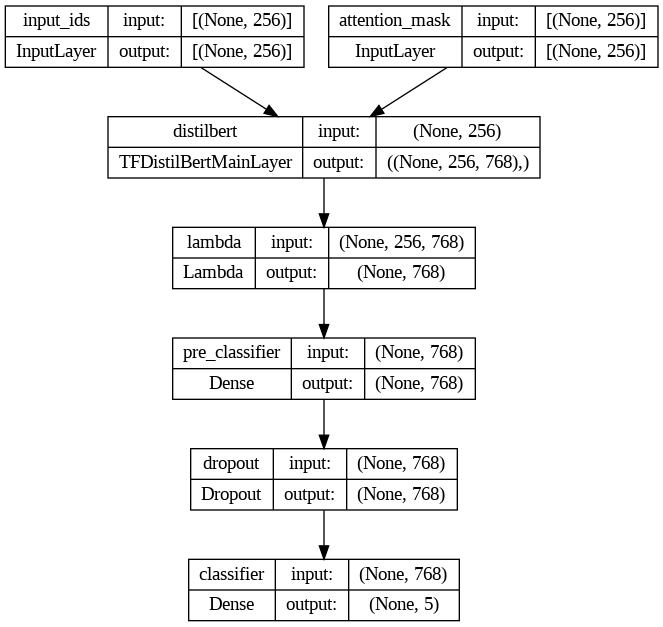

Done!


In [ ]:
# ==========================================================
# GENERAL CONFIGURATION
# ==========================================================

cfg = {}

cfg['framework'] = 'tf'
cfg['max_length'] = 256
cfg['transformer_model_name'] = 'distilbert-base-uncased'
cfg['num_labels'] = 5

# ==========================================================
# TOKENIZER
# ==========================================================

cfg['tokenizer'] = DistilBertTokenizer.from_pretrained(
    cfg['transformer_model_name']
)

# ==========================================================
# TF-IDF VECTORIZER
# ==========================================================

cfg['vectorizer'] = TfidfVectorizer(
    stop_words='english',
    max_features=10000
)

# training vectorizer
cfg['vectorizer'].fit(train[text_col].to_list())

# number of features TF-IDF
cfg['number_of_additional_features'] = len(
    cfg['vectorizer'].get_feature_names_out()
)

# guardar vectorizador
with open('vectorizer_reviews.pkl', 'wb') as f:
    pickle.dump(cfg['vectorizer'], f)

# ==========================================================
# LABEL BINARIZER
# ==========================================================

cfg['label_binarizer'] = preprocessing.MultiLabelBinarizer()

# train label binarizer
cfg['label_binarizer'].fit(train[class_col])

# save label binarizer
with open('label_binarizer_reviews.pkl', 'wb') as f:
    pickle.dump(cfg['label_binarizer'], f)

# ==========================================================
# MODELO
# ==========================================================

input_ids, input_masks, classifier = get_model_graph_sin_tfidf(cfg)

model = configure_model_sin_tfidf(input_ids,input_masks,classifier)

# print arquitechture
model.summary()

# visualize
model_image = plot_model(model,show_shapes=True,show_layer_names=True)

display(model_image)

# ==========================================================
# LABELS
# ==========================================================

# get labels
train_labels = train[emotions].values.astype('float32')
val_labels = val[emotions].values.astype('float32')

# transform labels 
train_labels_t = tf.convert_to_tensor(train_labels)
val_labels_t = tf.convert_to_tensor(val_labels)

# ==========================================================
# INPUTS
# ==========================================================

train_inputs = get_model_inputs(cfg,train[text_col].to_list())

val_inputs = get_model_inputs(cfg,val[text_col].to_list())

print('Done!')

### Training

In [ ]:
# config
cfg['checkpoints_dir'] = 'checkpoints'  # directory where checkpoints will be saved when training the model
cfg['model_name'] = 'experimento2'  # identificador al guardar los checkpoints
cfg['trained_model_name'] = os.path.join(cfg['checkpoints_dir'], cfg['model_name'])

epochs_max = 3
epochs_to_save = 1 # if epochs_max % epochs_to_save !=0 extra iterations might occur
batch_size = 64

# fine-tunning
for epoch_current in range(0, epochs_max, epochs_to_save):
    epoch_from = epoch_current +1
    epoch_to = epoch_current + epochs_to_save
    print(f'Training model, epochs {epoch_from} - {epoch_to}')

    # train the model. Optionally, validation data can be supplied => validation_data=(val_inputs,val_blabels_t)
    model.fit(train_inputs, y=train_labels_t, initial_epoch=epoch_current, epochs=epoch_to, batch_size=batch_size, validation_data=(val_inputs,val_labels_t))

    model.save_weights(cfg['trained_model_name'], save_format="tf")

print('Done!')

Training model, epochs 1 - 1


/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/functional.py:641: UserWarning: Input dict contained keys ['tfidf'] which did not match any model input. They will be ignored by the model.
  inputs = self._flatten_to_reference_inputs(inputs)
/usr/local/lib/python3.12/dist-packages/tf_keras/src/backend.py:5820: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


44/44 [==============================] - 102s 2s/step - loss: 0.5625 - binary_accuracy: 0.7152 - val_loss: 0.4983 - val_binary_accuracy: 0.7478
Training model, epochs 2 - 2
Epoch 2/2
44/44 [==============================] - 75s 2s/step - loss: 0.4254 - binary_accuracy: 0.8158 - val_loss: 0.4167 - val_binary_accuracy: 0.8070
Training model, epochs 3 - 3
Epoch 3/3
44/44 [==============================] - 75s 2s/step - loss: 0.3239 - binary_accuracy: 0.8697 - val_loss: 0.4210 - val_binary_accuracy: 0.8139
Done!


### Evaluation

In [ ]:
dict_resultados = {}
# predict the train data
true_labels = train[class_col]

m_pred = predict_model(model, cfg, train[text_col].to_list(), pref='m',threshold = 0.5)
dict_resultados['train'] = evaluate_model(true_labels, m_pred['labels_m'])

print('Done!')
# predict on the validation data

true_labels = val[class_col]
m_pred = predict_model(model, cfg, val[text_col].to_list(), pref='m')
dict_resultados['val'] = evaluate_model(true_labels, m_pred['labels_m'])
print('Done!')

/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/functional.py:641: UserWarning: Input dict contained keys ['tfidf'] which did not match any model input. They will be ignored by the model.
  inputs = self._flatten_to_reference_inputs(inputs)


87/87 [==============================] - 29s 317ms/step
==== Sumario de la clasificación ==== 
              precision    recall  f1-score   support

         joy       0.90      0.81      0.85       674
     sadness       0.86      0.86      0.86       876
    surprise       0.96      0.82      0.88       839
        fear       0.84      0.96      0.90      1610
       anger       0.95      0.58      0.72       333

   micro avg       0.88      0.86      0.87      4332
   macro avg       0.90      0.80      0.84      4332
weighted avg       0.89      0.86      0.87      4332
 samples avg       0.82      0.81      0.79      4332

Label Acc  : 91.87%
F1 Macro   : 84.24%
Recall     : 80.48%
Precision  : 90.21%
Done!
4/4 [==============================] - 1s 303ms/step
==== Sumario de la clasificación ==== 
              precision    recall  f1-score   support

         joy       0.72      0.42      0.53        31
     sadness       0.74      0.76      0.75        34
    surprise       0.

## Experiment 3: FocalLoss

### Configuration

In [ ]:
def configure_model_FL(input_ids, input_masks, input_tfidf, classifier):
    # define optimization algorithm
    optimizer = keras.optimizers.Adam(learning_rate=5e-5)

    # define loss function. It must be consistent with the expected model output (vector of num_labels elements)
    # and the format of examples (one-hot vector of num_labels components to encode categories)
    loss = keras.losses.BinaryFocalCrossentropy(gamma = 2.0,from_logits=True)

    # create model
    model = keras.Model(inputs=[input_ids, input_masks, input_tfidf], outputs=classifier, name='distilbert-custom')

    # compile the model, specifying other metrics to monitor
    # The metric must be appropriate for the type of problem (binary or multiclass classification)
    model.compile(optimizer=optimizer, loss=loss, metrics=['binary_accuracy'])

    return model


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_transform.bias', 'vocab_projector.bias', 'vocab_transform.weight', 'vocab_layer_norm.bias', 'vocab_layer_norm.weight']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a Bert

Model: "distilbert-custom"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, 256)]                0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, 256)]                0         []                            
 )                                                                                                
                                                                                                  
 distilbert (TFDistilBertMa  ((None, 256, 768),           6636288   ['input_ids[0][0]',           
 inLayer)                    )                            0          'attention_mask[0][0]']      
                                                                                  

/usr/local/lib/python3.12/dist-packages/tf_keras/src/initializers/initializers.py:121: UserWarning: The initializer TruncatedNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


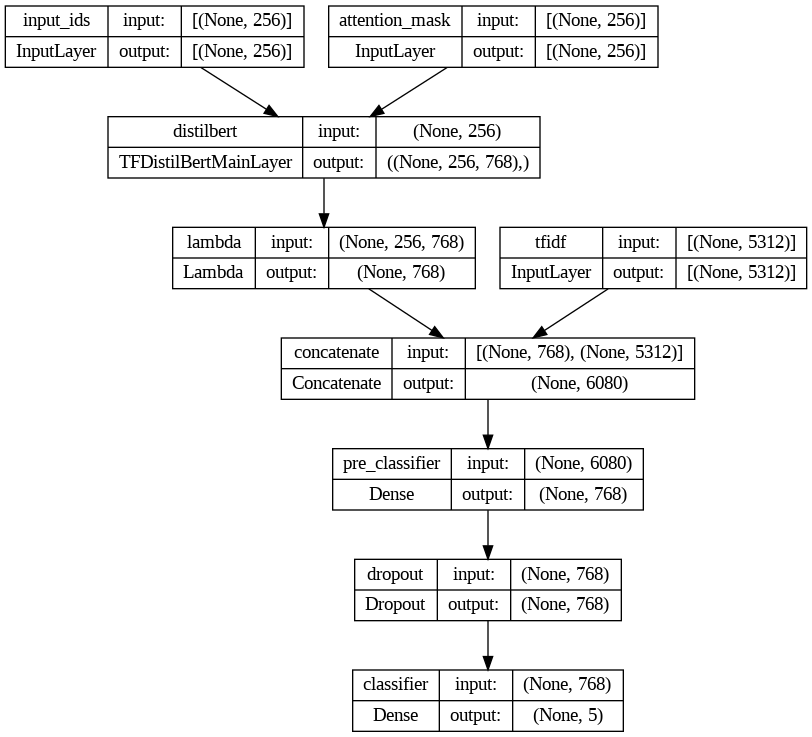


✓ Configuración completa
✓ Class weights guardados en class_weights.pkl


In [ ]:
# ==========================================================
# GENERAL CONFIGURATION
# ==========================================================

cfg = {}

cfg['framework'] = 'tf'
cfg['max_length'] = 256
cfg['transformer_model_name'] = 'distilbert-base-uncased'
cfg['num_labels'] = 5

# ==========================================================
# TOKENIZER
# ==========================================================

cfg['tokenizer'] = DistilBertTokenizer.from_pretrained(
    cfg['transformer_model_name']
)

# ==========================================================
# TF-IDF VECTORIZER
# ==========================================================

cfg['vectorizer'] = TfidfVectorizer(
    stop_words='english',
    max_features=10000
)


cfg['vectorizer'].fit(train[text_col].to_list())

cfg['number_of_additional_features'] = len(
    cfg['vectorizer'].get_feature_names_out()
)

with open('vectorizer_weighted.pkl', 'wb') as f:
    pickle.dump(cfg['vectorizer'], f)

# ==========================================================
# LABEL BINARIZER
# ==========================================================

cfg['label_binarizer'] = preprocessing.MultiLabelBinarizer()


cfg['label_binarizer'].fit(train[class_col])


with open('label_binarizer_weighted.pkl', 'wb') as f:
    pickle.dump(cfg['label_binarizer'], f)

# ==========================================================
# MODELO
# ==========================================================

input_ids, input_masks, input_tfidf, classifier = get_model_graph(cfg)

model = configure_model_FL(input_ids, input_masks, input_tfidf, classifier)


model.summary()


model_image = plot_model(
    model,
    show_shapes=True,
    show_layer_names=True
)

display(model_image)

# ==========================================================
# LABELS
# ==========================================================


train_labels = train[emotions].values.astype('float32')
val_labels = val[emotions].values.astype('float32')


train_labels_t = tf.convert_to_tensor(train_labels)
val_labels_t = tf.convert_to_tensor(val_labels)

# ==========================================================
# INPUTS DEL MODELO
# ==========================================================

train_inputs = get_model_inputs(cfg, train[text_col].to_list())

val_inputs = get_model_inputs(cfg, val[text_col].to_list())


print('\n✓ Configuration complete')
print(f'✓ Class weights guardados en class_weights.pkl')

### Training

In [ ]:
# config
cfg['checkpoints_dir'] = 'checkpoints'  # directory where checkpoints will be saved when training the model
cfg['model_name'] = 'experimento3' 
cfg['trained_model_name'] = os.path.join(cfg['checkpoints_dir'], cfg['model_name'])

epochs_max = 3
epochs_to_save = 1 # if epochs_max % epochs_to_save !=0 extra iterations might occur
batch_size = 64

# fine-tunning
for epoch_current in range(0, epochs_max, epochs_to_save):
    epoch_from = epoch_current +1
    epoch_to = epoch_current + epochs_to_save
    print(f'Training model, epochs {epoch_from} - {epoch_to}')

    # train the model. Optionally, validation data can be supplied => validation_data=(val_inputs,val_blabels_t)
    model.fit(train_inputs, y=train_labels_t, initial_epoch=epoch_current, epochs=epoch_to, batch_size=batch_size, validation_data=(val_inputs,val_labels_t))

    model.save_weights(cfg['trained_model_name'], save_format="tf")

print('Done!')

Training model, epochs 1 - 1
44/44 [==============================] - 104s 2s/step - loss: 0.1307 - binary_accuracy: 0.7093 - val_loss: 0.1103 - val_binary_accuracy: 0.7287
Training model, epochs 2 - 2
Epoch 2/2
44/44 [==============================] - 75s 2s/step - loss: 0.0955 - binary_accuracy: 0.7839 - val_loss: 0.0997 - val_binary_accuracy: 0.7983
Training model, epochs 3 - 3
Epoch 3/3
44/44 [==============================] - 75s 2s/step - loss: 0.0677 - binary_accuracy: 0.8572 - val_loss: 0.1035 - val_binary_accuracy: 0.8070
Done!


### Evaluation

In [ ]:
dict_resultados = {}
# predict training data
true_labels = train[class_col]

m_pred = predict_model(model, cfg, train[text_col].to_list(), pref='m',threshold = 0.5)
dict_resultados['train'] = evaluate_model(true_labels, m_pred['labels_m'])

print('Done!')
# predict on the validation data

true_labels = val[class_col]
m_pred = predict_model(model, cfg, val[text_col].to_list(), pref='m')
dict_resultados['val'] = evaluate_model(true_labels, m_pred['labels_m'])
print('Done!')

87/87 [==============================] - 29s 318ms/step
==== Sumario de la clasificación ==== 
              precision    recall  f1-score   support

         joy       0.99      0.57      0.72       674
     sadness       0.97      0.66      0.79       876
    surprise       0.99      0.51      0.67       839
        fear       0.99      0.75      0.85      1610
       anger       0.97      0.66      0.79       333

   micro avg       0.99      0.65      0.78      4332
   macro avg       0.98      0.63      0.76      4332
weighted avg       0.99      0.65      0.78      4332
 samples avg       0.72      0.60      0.64      4332

Label Acc  : 88.70%
F1 Macro   : 76.35%
Recall     : 62.87%
Precision  : 98.35%
Done!
4/4 [==============================] - 1s 303ms/step
==== Sumario de la clasificación ==== 
              precision    recall  f1-score   support

         joy       1.00      0.29      0.45        31
     sadness       0.95      0.53      0.68        34
    surprise       0.

## Experiment 4: Class Weight

In [ ]:

sample_weights = np.ones(len(train))

print("\nCalculando sample weights...")

for i, emotion in enumerate(emotions):
    # calculate weights for this emotion
    weights = compute_class_weight(
        'balanced',
        classes=np.array([0, 1]),
        y=train[emotion].values
    )

    # applying a greater weight to classes with less samples 
    mask_positive = train[emotion] == 1
    sample_weights[mask_positive] *= weights[1]

    mask_negative = train[emotion] == 0
    sample_weights[mask_negative] *= weights[0]

# normalize weights 
sample_weights = sample_weights / sample_weights.mean()

print(f"✓ Sample weights calculados")
print(f"  Min weight: {sample_weights.min():.4f}")
print(f"  Max weight: {sample_weights.max():.4f}")
print(f"  Mean weight: {sample_weights.mean():.4f}")

# transform to tensors
sample_weights_t = tf.convert_to_tensor(sample_weights, dtype='float32')


Calculando sample weights...
✓ Sample weights calculados
  Min weight: 0.2010
  Max weight: 22.5044
  Mean weight: 1.0000


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_transform.bias', 'vocab_projector.bias', 'vocab_transform.weight', 'vocab_layer_norm.bias', 'vocab_layer_norm.weight']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a Bert

Model: "distilbert-custom"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, 256)]                0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, 256)]                0         []                            
 )                                                                                                
                                                                                                  
 distilbert (TFDistilBertMa  ((None, 256, 768),           6636288   ['input_ids[0][0]',           
 inLayer)                    )                            0          'attention_mask[0][0]']      
                                                                                  

/usr/local/lib/python3.12/dist-packages/tf_keras/src/initializers/initializers.py:121: UserWarning: The initializer TruncatedNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


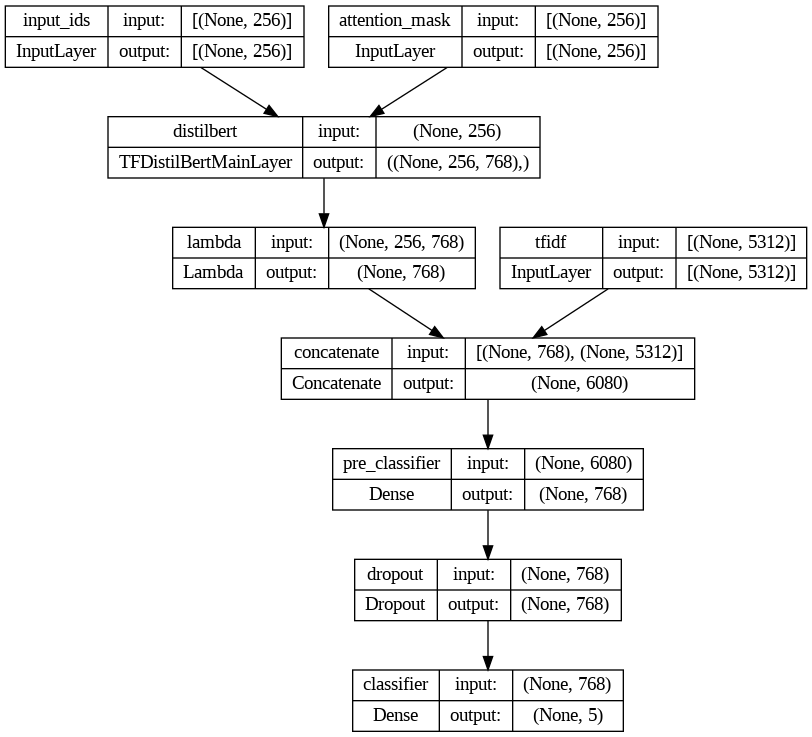


✓ Configuración completa
✓ Class weights guardados en class_weights.pkl


In [ ]:
# ==========================================================
# GENERAL CONFIGURATION
# ==========================================================

cfg = {}

cfg['framework'] = 'tf'
cfg['max_length'] = 256
cfg['transformer_model_name'] = 'distilbert-base-uncased'
cfg['num_labels'] = 5

# ==========================================================
# TOKENIZER
# ==========================================================

cfg['tokenizer'] = DistilBertTokenizer.from_pretrained(
    cfg['transformer_model_name']
)

# ==========================================================
# TF-IDF VECTORIZER
# ==========================================================

cfg['vectorizer'] = TfidfVectorizer(
    stop_words='english',
    max_features=10000
)


cfg['vectorizer'].fit(train[text_col].to_list())


cfg['number_of_additional_features'] = len(
    cfg['vectorizer'].get_feature_names_out()
)

# guardar vectorizador
with open('vectorizer_weighted.pkl', 'wb') as f:
    pickle.dump(cfg['vectorizer'], f)

# ==========================================================
# LABEL BINARIZER
# ==========================================================

cfg['label_binarizer'] = preprocessing.MultiLabelBinarizer()


cfg['label_binarizer'].fit(train[class_col])


with open('label_binarizer_weighted.pkl', 'wb') as f:
    pickle.dump(cfg['label_binarizer'], f)

# ==========================================================
# MODELO
# ==========================================================

input_ids, input_masks, input_tfidf, classifier = get_model_graph(cfg)

model = configure_model(input_ids, input_masks, input_tfidf, classifier)


model.summary()


model_image = plot_model(
    model,
    show_shapes=True,
    show_layer_names=True
)

display(model_image)

# ==========================================================
# LABELS
# ==========================================================


train_labels = train[emotions].values.astype('float32')
val_labels = val[emotions].values.astype('float32')


train_labels_t = tf.convert_to_tensor(train_labels)
val_labels_t = tf.convert_to_tensor(val_labels)

# ==========================================================
# INPUTS DEL MODELO
# ==========================================================

train_inputs = get_model_inputs(cfg, train[text_col].to_list())

val_inputs = get_model_inputs(cfg, val[text_col].to_list())


print('\n✓ Configuration complete')
print(f'✓ Class weights guardados en class_weights.pkl')

### Training

In [ ]:
# config
cfg['checkpoints_dir'] = 'checkpoints'
cfg['model_name'] = 'experimento4'
cfg['trained_model_name'] = os.path.join(cfg['checkpoints_dir'], cfg['model_name'])

epochs_max = 3
epochs_to_save = 1
batch_size = 32

print("Entrenando modelo con class weights...")
print(f"Epochs: {epochs_max}")
print(f"Batch size: {batch_size}")
print("-" * 60)

# fine-tunning
for epoch_current in range(0, epochs_max, epochs_to_save):
    epoch_from = epoch_current + 1
    epoch_to = epoch_current + epochs_to_save
    print(f'\nTraining model, epochs {epoch_from} - {epoch_to}')

    # train with class_weight
    model.fit(
        train_inputs,
        y=train_labels_t,
        sample_weight=sample_weights_t,  # usar sample weights
        initial_epoch=epoch_current,
        epochs=epoch_to,
        batch_size=batch_size,
        validation_data=(val_inputs, val_labels_t)
    )

    # guardar checkpoint
    model.save_weights(cfg['trained_model_name'], save_format="tf")
    print(f"✓ Checkpoint guardado: {cfg['trained_model_name']}")

print('\n✓ Training complete')

Entrenando modelo con class weights...
Epochs: 3
Batch size: 32
------------------------------------------------------------

Training model, epochs 1 - 1
87/87 [==============================] - 103s 896ms/step - loss: 0.6106 - binary_accuracy: 0.7219 - val_loss: 0.5483 - val_binary_accuracy: 0.7913
✓ Checkpoint guardado: checkpoints/experimento4

Training model, epochs 2 - 2
Epoch 2/2
87/87 [==============================] - 75s 867ms/step - loss: 0.4575 - binary_accuracy: 0.7998 - val_loss: 0.4537 - val_binary_accuracy: 0.8122
✓ Checkpoint guardado: checkpoints/experimento4

Training model, epochs 3 - 3
Epoch 3/3
87/87 [==============================] - 75s 864ms/step - loss: 0.3322 - binary_accuracy: 0.8534 - val_loss: 0.4156 - val_binary_accuracy: 0.8174
✓ Checkpoint guardado: checkpoints/experimento4

✓ Entrenamiento completado


### Evaluation

In [ ]:
dict_resultados = {}

In [ ]:

true_labels = train[class_col]

m_pred = predict_model(model, cfg, train[text_col].to_list(), pref='m',threshold = 0.5)
dict_resultados['train'] = evaluate_model(true_labels, m_pred['labels_m'])

print('Done!')

87/87 [==============================] - 29s 317ms/step
==== Sumario de la clasificación ==== 
              precision    recall  f1-score   support

         joy       0.90      0.84      0.87       674
     sadness       0.89      0.64      0.75       876
    surprise       0.85      0.82      0.83       839
        fear       0.93      0.80      0.86      1610
       anger       0.74      0.94      0.83       333

   micro avg       0.88      0.79      0.83      4332
   macro avg       0.86      0.81      0.83      4332
weighted avg       0.88      0.79      0.83      4332
 samples avg       0.76      0.72      0.72      4332

Label Acc  : 89.96%
F1 Macro   : 82.67%
Recall     : 80.88%
Precision  : 86.02%
Done!


In [ ]:


true_labels = val[class_col]
m_pred = predict_model(model, cfg, val[text_col].to_list(), pref='m')
dict_resultados['val'] = evaluate_model(true_labels, m_pred['labels_m'])
print('Done!')

4/4 [==============================] - 1s 305ms/step
==== Sumario de la clasificación ==== 
              precision    recall  f1-score   support

         joy       0.88      0.48      0.62        31
     sadness       0.90      0.56      0.69        34
    surprise       0.64      0.74      0.69        31
        fear       0.75      0.63      0.68        62
       anger       0.57      0.81      0.67        16

   micro avg       0.73      0.63      0.67       174
   macro avg       0.75      0.65      0.67       174
weighted avg       0.77      0.63      0.67       174
 samples avg       0.62      0.57      0.57       174

Label Acc  : 81.74%
F1 Macro   : 67.07%
Recall     : 64.52%
Precision  : 74.82%
Done!


In [ ]:
# configuraciones
cfg['stats_dir'] = 'stats'  # directory where evaluation results will be saved
cfg['model_name'] = 'experimento4'


os.makedirs(cfg['stats_dir'], exist_ok=True)


ruta = os.path.join(cfg['stats_dir'], f'{cfg["model_name"]}_results.json')

with open(ruta, "w", encoding="utf-8") as f:
    json.dump(dict_resultados, f, indent=4, ensure_ascii=False)

## Experiment 5: Change Architecture and Implement an Attention Mask

In [ ]:
def get_model_graph_attention_mask(cfg):
  transformer = TFDistilBertModel.from_pretrained(cfg['transformer_model_name'], return_dict=False).distilbert

  # create variable that will represent id inputs for the Transformer
  input_ids = keras.layers.Input(shape=(cfg['max_length'],), name='input_ids', dtype='int32')

  # create variable that will represent mask inputs for the Transformer
  input_masks = keras.layers.Input(shape=(cfg['max_length'],), name='attention_mask', dtype='int32')

  # create variable that will represent inputs corresponding to domain-specific features.
  input_tfidf = keras.layers.Input(shape=(cfg['number_of_additional_features'],), name='tfidf', dtype='float32')

  # There are several criteria (e.g. https://arxiv.org/pdf/1908.10084.pdf) on which components to use as features,
  # en este caso, tomaremos el embedding correspondiente al token de inicio de texto [CLS] de modo similar a TFDistilBertForSequenceClassification
  transformer_output = transformer(input_ids, attention_mask=input_masks)

  # ===== CHANGE: USING ALL TOKENS INSTEAD OF USING [CLS] =====
  # the transformation will depend on the output type of the Transformer used, in this case TFDistilBertMainLayer
  # whose output is a tuple of a single element, containing an array of dimensions
  # (number_of_instances, number_of_tokens, embedding_dimension)
  sequence_output = transformer_output[0]  # Todos los tokens (batch, seq_len, 768)

  # Apply attention pooling: learn which tokens are most important for emotions
  attention_weights = keras.layers.Dense(1, activation='tanh', name='attention_weights')(sequence_output)
  attention_weights = keras.layers.Softmax(axis=1, name='attention_softmax')(attention_weights)

  context_vector = keras.layers.Dot(axes=[1, 1], name='context_vector')([attention_weights, sequence_output])
  context_vector = keras.layers.Flatten(name='flatten_context')(context_vector)
  # ===== END CHANGE =====

  # ===== CHANGE: Usar context_vector en lugar de transformes_cls_embedding =====
  features = keras.layers.concatenate([context_vector, input_tfidf], name='concatenate')
  # ===== END CHANGE =====

  # set some model hyperparameters
  initializer_range = 0.02
  hiden_units = 768
  seq_classif_dropout=0.2
  initializer = keras.initializers.TruncatedNormal(stddev=initializer_range)

  # ===== CHANGE: Add Batch Normalization =====
  batch_norm = keras.layers.BatchNormalization(name='batch_norm')(features)
  # ===== END CHANGE =====

  # ===== CHANGE: Using batch_norm  =====
  pre_classifier = keras.layers.Dense(hiden_units, kernel_initializer=initializer, activation='relu', name='pre_classifier')(batch_norm)
  # ===== END CHANGE =====

  # create dropout layer
  dropout_layer = keras.layers.Dropout(rate=seq_classif_dropout, name='dropout')(pre_classifier)

  # ===== CHANGE: Add sigmoid activation for multi-label =====
  classifier = keras.layers.Dense(cfg['num_labels'], kernel_initializer=initializer, activation='sigmoid', name='classifier')(dropout_layer)
  # ===== END CHANGE =====

  return input_ids, input_masks, input_tfidf, classifier

print('Done!')

Done!


### Configuration

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_transform.bias', 'vocab_projector.bias', 'vocab_transform.weight', 'vocab_layer_norm.bias', 'vocab_layer_norm.weight']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a Bert

Model: "distilbert-custom"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, 256)]                0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, 256)]                0         []                            
 )                                                                                                
                                                                                                  
 distilbert (TFDistilBertMa  ((None, 256, 768),           6636288   ['input_ids[0][0]',           
 inLayer)                    )                            0          'attention_mask[0][0]']      
                                                                                  

/usr/local/lib/python3.12/dist-packages/tf_keras/src/initializers/initializers.py:121: UserWarning: The initializer TruncatedNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


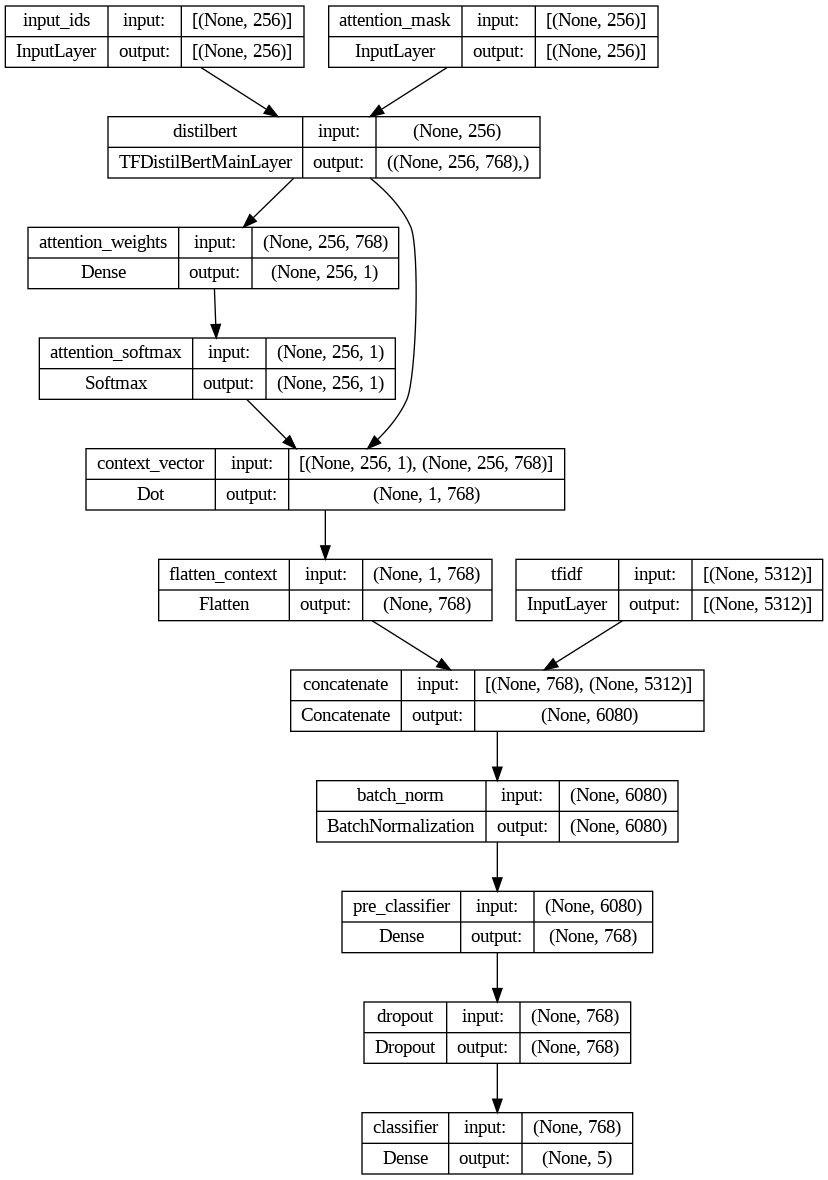

Done!


In [ ]:
# ==========================================================
# GENERAL CONFIGURATION
# ==========================================================

cfg = {}

cfg['framework'] = 'tf'
cfg['max_length'] = 256
cfg['transformer_model_name'] = 'distilbert-base-uncased'
cfg['num_labels'] = 5

# ==========================================================
# TOKENIZER
# ==========================================================

cfg['tokenizer'] = DistilBertTokenizer.from_pretrained(
    cfg['transformer_model_name']
)

# ==========================================================
# TF-IDF VECTORIZER
# ==========================================================

cfg['vectorizer'] = TfidfVectorizer(stop_words='english',max_features=10000)


cfg['vectorizer'].fit(train[text_col].to_list())


cfg['number_of_additional_features'] = len(
    cfg['vectorizer'].get_feature_names_out()
)


with open('vectorizer_reviews.pkl', 'wb') as f:
    pickle.dump(cfg['vectorizer'], f)

# ==========================================================
# LABEL BINARIZER
# ==========================================================

cfg['label_binarizer'] = preprocessing.MultiLabelBinarizer()


cfg['label_binarizer'].fit(train[class_col])


with open('label_binarizer_reviews.pkl', 'wb') as f:
    pickle.dump(cfg['label_binarizer'], f)

# ==========================================================
# MODEL
# ==========================================================

input_ids, input_masks, input_tfidf, classifier = get_model_graph_attention_mask(cfg)

model = configure_model(input_ids,input_masks,input_tfidf,classifier)


model.summary()


model_image = tf.keras.utils.plot_model(model,show_shapes=True,show_layer_names=True)

display(model_image)

# ==========================================================
# LABELS
# ==========================================================



train_labels = train[emotions].values.astype('float32')
val_labels = val[emotions].values.astype('float32')

train_labels_t = tf.convert_to_tensor(train_labels)
val_labels_t = tf.convert_to_tensor(val_labels)

# ==========================================================
# INPUTS
# ==========================================================

train_inputs = get_model_inputs(cfg,train[text_col].to_list())

val_inputs = get_model_inputs(cfg,val[text_col].to_list())

print('Done!')

Building NEW model...
Model will expect TF-IDF size: 5312


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_transform.bias', 'vocab_projector.bias', 'vocab_transform.weight', 'vocab_layer_norm.bias', 'vocab_layer_norm.weight']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBer

Model: "distilbert-custom"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, 256)]                0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, 256)]                0         []                            
 )                                                                                                
                                                                                                  
 distilbert (TFDistilBertMa  ((None, 256, 768),           6636288   ['input_ids[0][0]',           
 inLayer)                    )                            0          'attention_mask[0][0]']      
                                                                                  

/usr/local/lib/python3.12/dist-packages/tf_keras/src/initializers/initializers.py:121: UserWarning: The initializer TruncatedNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


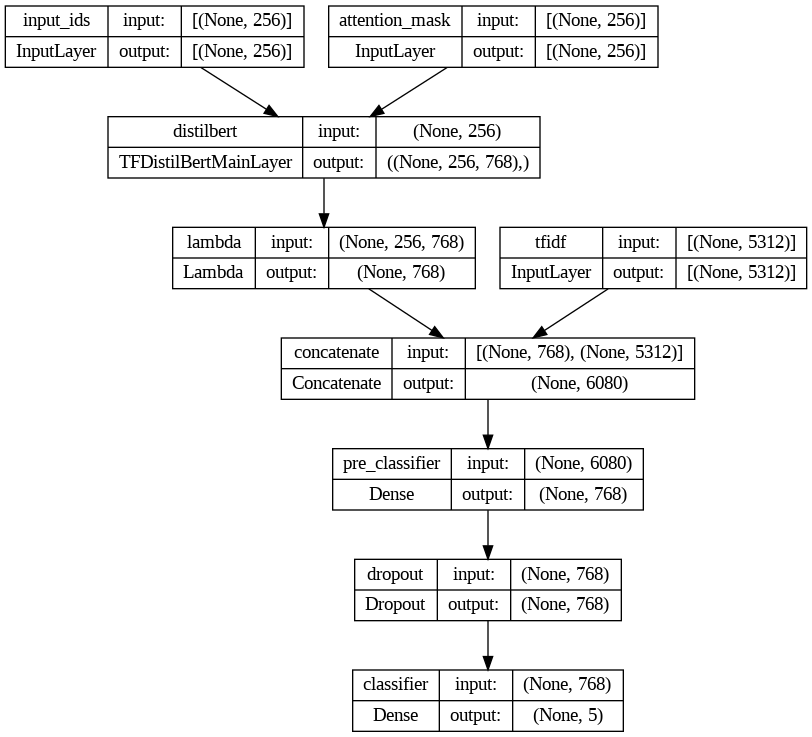


✓ Model TF-IDF input layer shape: [(None, 5312)]
✓ Data TF-IDF shape: (2764, 5312)
✓ Model built successfully!


In [ ]:

print("Building NEW model...")
print(f"Model will expect TF-IDF size: {cfg['number_of_additional_features']}")

input_ids, input_masks, input_tfidf, classifier = get_model_graph(cfg)
model = configure_model(input_ids, input_masks, input_tfidf, classifier)

model.summary()
model_image = tf.keras.utils.plot_model(model, show_shapes=True, show_layer_names=True)
display(model_image)

# Verify that the input layer has the correct size
tfidf_input_shape = model.get_layer('tfidf').output_shape
print(f"\n✓ Model TF-IDF input layer shape: {tfidf_input_shape}")
print(f"✓ Data TF-IDF shape: {train_inputs['tfidf'].shape}")

print('✓ Model built successfully!')

### Training

In [ ]:
# config
cfg['checkpoints_dir'] = 'checkpoints'  # directory where checkpoints will be saved when training the model
cfg['model_name'] = 'experimento5'
cfg['trained_model_name'] = os.path.join(cfg['checkpoints_dir'], cfg['model_name'])

epochs_max = 3
epochs_to_save = 1 # if epochs_max % epochs_to_save !=0 extra iterations might occur
batch_size = 64

# fine-tunning
for epoch_current in range(0, epochs_max, epochs_to_save):
    epoch_from = epoch_current +1
    epoch_to = epoch_current + epochs_to_save
    print(f'Training model, epochs {epoch_from} - {epoch_to}')

    # train the model. Optionally, validation data can be supplied => validation_data=(val_inputs,val_blabels_t)
    model.fit(train_inputs, y=train_labels_t, initial_epoch=epoch_current, epochs=epoch_to, batch_size=batch_size, validation_data=(val_inputs,val_labels_t))

    model.save_weights(cfg['trained_model_name'], save_format="tf")

print('Done!')

Training model, epochs 1 - 1
44/44 [==============================] - 102s 2s/step - loss: 0.5650 - binary_accuracy: 0.7159 - val_loss: 0.4858 - val_binary_accuracy: 0.7374
Training model, epochs 2 - 2
Epoch 2/2
44/44 [==============================] - 75s 2s/step - loss: 0.4237 - binary_accuracy: 0.7952 - val_loss: 0.4353 - val_binary_accuracy: 0.7809
Training model, epochs 3 - 3
Epoch 3/3
44/44 [==============================] - 75s 2s/step - loss: 0.3190 - binary_accuracy: 0.8643 - val_loss: 0.3991 - val_binary_accuracy: 0.8122
Done!


### Evaluation

In [ ]:
dict_resultados = {}

In [ ]:

true_labels = train[class_col]

m_pred = predict_model(model, cfg, train[text_col].to_list(), pref='m')

dict_resultados['train'] = evaluate_model(true_labels, m_pred['labels_m'])

print('Done!')

87/87 [==============================] - 29s 312ms/step
==== Sumario de la clasificación ==== 
              precision    recall  f1-score   support

         joy       0.86      0.82      0.84       674
     sadness       0.90      0.83      0.86       876
    surprise       0.97      0.67      0.79       839
        fear       0.94      0.92      0.93      1610
       anger       0.96      0.41      0.58       333

   micro avg       0.92      0.80      0.86      4332
   macro avg       0.93      0.73      0.80      4332
weighted avg       0.93      0.80      0.85      4332
 samples avg       0.83      0.76      0.78      4332

Label Acc  : 91.64%
F1 Macro   : 80.12%
Recall     : 73.11%
Precision  : 92.79%
Done!


In [ ]:
# predict on the validation data

true_labels = val[class_col]
m_pred = predict_model(model, cfg, val[text_col].to_list(), pref='m')
dict_resultados['val'] = evaluate_model(true_labels, m_pred['labels_m'])  

print('Done!')

4/4 [==============================] - 1s 290ms/step
==== Sumario de la clasificación ==== 
              precision    recall  f1-score   support

         joy       0.84      0.52      0.64        31
     sadness       0.76      0.65      0.70        34
    surprise       0.63      0.39      0.48        31
        fear       0.70      0.73      0.71        62
       anger       1.00      0.44      0.61        16

   micro avg       0.74      0.59      0.65       174
   macro avg       0.79      0.54      0.63       174
weighted avg       0.75      0.59      0.65       174
 samples avg       0.63      0.56      0.56       174

Label Acc  : 81.22%
F1 Macro   : 62.83%
Recall     : 54.27%
Precision  : 78.71%
Done!


In [ ]:

cfg['stats_dir'] = 'stats'
cfg['model_name'] = 'experimento5'


os.makedirs(cfg['stats_dir'], exist_ok=True)


ruta = os.path.join(cfg['stats_dir'], f'{cfg["model_name"]}_results.json')

with open(ruta, "w", encoding="utf-8") as f:
    json.dump(dict_resultados, f, indent=4, ensure_ascii=False)

## Experiment 6: MultiHeadAttention

In [ ]:
def get_model_graph_multiheadattention(cfg):
  # load the layer that represents the Transformer,
  # in this case TFDistilBertMainLayer
  transformer = TFDistilBertModel.from_pretrained(
      cfg['transformer_model_name'],
      return_dict=False
  ).distilbert

  # create the placeholders corresponding to the model inputs

  # create variable that will represent id inputs for the Transformer
  input_ids = keras.layers.Input(
      shape=(cfg['max_length'],),
      name='input_ids',
      dtype='int32'
  )

  # create variable that will represent mask inputs for the Transformer
  input_masks = keras.layers.Input(
      shape=(cfg['max_length'],),
      name='attention_mask',
      dtype='int32'
  )

  # create variable that will represent inputs corresponding
  # to domain-specific features
  input_tfidf = keras.layers.Input(
      shape=(cfg['number_of_additional_features'],),
      name='tfidf',
      dtype='float32'
  )

  # indicate that TFDistilBertMainLayer is called with
  # input_ids and input_mask and capture its output,
  # which contains the embeddings corresponding
  # to each token in the text
  #
  # There are several criteria (e.g. https://arxiv.org/pdf/1908.10084.pdf)
  # regarding which components should be used as features.
  #
  # In this case we will use ALL token embeddings
  # instead of only the [CLS] embedding
  transformer_output = transformer(
      input_ids,
      attention_mask=input_masks
  )

  # ===== CHANGE: Use all tokens instead of only [CLS] =====
  #
  # extract all sequence embeddings
  #
  # the transformation will depend on the output type of
  # the Transformer used, in this case TFDistilBertMainLayer,
  # whose output is a tuple containing a single element
  # with dimensions:
  #
  # (number_of_instances, number_of_tokens, embedding_dimension)
  sequence_output = transformer_output[0]
  # shape -> (batch, seq_len, 768)

  # ==========================================================
  # ===== CHANGE: Add MultiHead Self-Attention ===============
  # ==========================================================
  #
  # Allows the model to learn relationships between
  # different tokens in the sequence in order to better
  # detect complex emotions.
  #
  # query = value = key = sequence_output
  # because this is self-attention
  multihead_attention = keras.layers.MultiHeadAttention(
      num_heads=8,
      key_dim=64,
      dropout=0.1,
      name='multihead_attention'
  )(
      query=sequence_output,
      value=sequence_output,
      key=sequence_output
  )

  # ===== CHANGE: Add residual connection =====
  #
  # Helps stabilize training and preserve
  # the original Transformer information
  attention_residual = keras.layers.Add(
      name='attention_residual'
  )([sequence_output, multihead_attention])

  # ===== CHANGE: Add layer normalization =====
  #
  # Improves numerical stability and convergence
  attention_norm = keras.layers.LayerNormalization(
      epsilon=1e-6,
      name='attention_norm'
  )(attention_residual)

  # ==========================================================
  # ===== CHANGE: Attention Pooling ==========================
  # ==========================================================
  #
  # Learn which tokens are most important
  # for emotion classification
  attention_weights = keras.layers.Dense(
      1,
      activation='tanh',
      name='attention_weights'
  )(attention_norm)

  # Normalize attention weights
  attention_weights = keras.layers.Softmax(
      axis=1,
      name='attention_softmax'
  )(attention_weights)

  # Compute the weighted sum of all token representations
  context_vector = keras.layers.Dot(
      axes=[1, 1],
      name='context_vector'
  )([attention_weights, attention_norm])

  # Convert to a flat vector
  context_vector = keras.layers.Flatten(
      name='flatten_context'
  )(context_vector)

  # ===== END CHANGE =====

  # Concatenate the contextual embedding
  # with the additional feature vector
  #
  # ===== CHANGE: Use context_vector instead of [CLS] =====
  features = keras.layers.concatenate(
      [context_vector, input_tfidf],
      name='concatenate'
  )
  # ===== END CHANGE =====

  # Set model hyperparameters
  initializer_range = 0.02
  hidden_units = 768
  seq_classif_dropout = 0.2

  initializer = keras.initializers.TruncatedNormal(
      stddev=initializer_range
  )

  # ===== CHANGE: Add Batch Normalization =====
  #
  # Helps stabilize training and reduce overfitting
  batch_norm = keras.layers.BatchNormalization(
      name='batch_norm'
  )(features)
  # ===== END CHANGE =====

  # Create pre-classifier and use the normalized
  # concatenated features as input
  #
  # ===== CHANGE: Use batch_norm as input =====
  pre_classifier = keras.layers.Dense(
      hidden_units,
      kernel_initializer=initializer,
      activation='relu',
      name='pre_classifier'
  )(batch_norm)
  # ===== END CHANGE =====

  # Create dropout layer and use the output
  # of pre_classifier as input
  dropout_layer = keras.layers.Dropout(
      rate=seq_classif_dropout,
      name='dropout'
  )(pre_classifier)

  # Create classifier layer and use
  # the dropout output as input
  #
  # ===== CHANGE: Use sigmoid activation for multi-label =====
  classifier = keras.layers.Dense(
      cfg['num_labels'],
      kernel_initializer=initializer,
      activation='sigmoid',
      name='classifier'
  )(dropout_layer)
  # ===== END CHANGE =====

  return input_ids, input_masks, input_tfidf, classifier


print('Done!')

Done!


### Configuration

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_transform.bias', 'vocab_projector.bias', 'vocab_transform.weight', 'vocab_layer_norm.bias', 'vocab_layer_norm.weight']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a Bert

Model: "distilbert-custom"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, 256)]                0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, 256)]                0         []                            
 )                                                                                                
                                                                                                  
 distilbert (TFDistilBertMa  ((None, 256, 768),           6636288   ['input_ids[0][0]',           
 inLayer)                    )                            0          'attention_mask[0][0]']      
                                                                                  

/usr/local/lib/python3.12/dist-packages/tf_keras/src/initializers/initializers.py:121: UserWarning: The initializer TruncatedNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


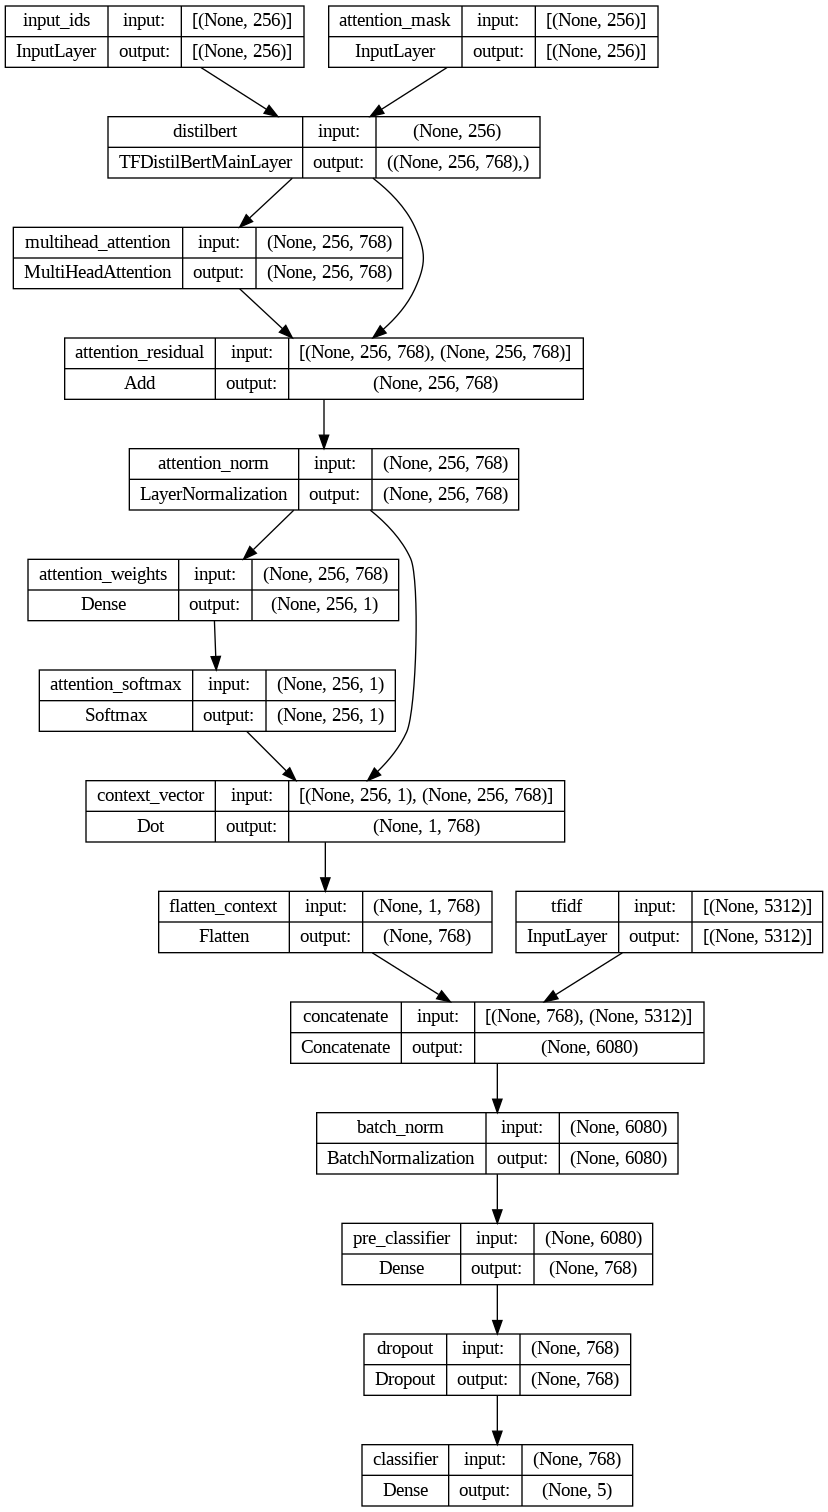

Done!


In [ ]:
# ==========================================================
# GENERAL CONFIGURATION
# ==========================================================

cfg = {}

cfg['framework'] = 'tf'
cfg['max_length'] = 256
cfg['transformer_model_name'] = 'distilbert-base-uncased'
cfg['num_labels'] = 5

# ==========================================================
# TOKENIZER
# ==========================================================

cfg['tokenizer'] = DistilBertTokenizer.from_pretrained(
    cfg['transformer_model_name']
)

# ==========================================================
# TF-IDF VECTORIZER
# ==========================================================

cfg['vectorizer'] = TfidfVectorizer(stop_words='english',max_features=10000)


cfg['vectorizer'].fit(train[text_col].to_list())


cfg['number_of_additional_features'] = len(
    cfg['vectorizer'].get_feature_names_out()
)

# guardar vectorizador
with open('vectorizer_reviews.pkl', 'wb') as f:
    pickle.dump(cfg['vectorizer'], f)

# ==========================================================
# LABEL BINARIZER
# ==========================================================

cfg['label_binarizer'] = preprocessing.MultiLabelBinarizer()


cfg['label_binarizer'].fit(train[class_col])


with open('label_binarizer_reviews.pkl', 'wb') as f:
    pickle.dump(cfg['label_binarizer'], f)

# ==========================================================
# MODELO
# ==========================================================

input_ids, input_masks, input_tfidf, classifier = get_model_graph_multiheadattention(cfg)

model = configure_model(input_ids,input_masks,input_tfidf,classifier)


model.summary()


model_image = tf.keras.utils.plot_model(model,show_shapes=True,show_layer_names=True)

display(model_image)

# ==========================================================
# LABELS
# ==========================================================


train_labels = train[emotions].values.astype('float32')
val_labels = val[emotions].values.astype('float32')


train_labels_t = tf.convert_to_tensor(train_labels)
val_labels_t = tf.convert_to_tensor(val_labels)

# ==========================================================
# INPUTS DEL MODELO
# ==========================================================

train_inputs = get_model_inputs(cfg,train[text_col].to_list())

val_inputs = get_model_inputs(cfg,val[text_col].to_list())

print('Done!')

In [ ]:

print("Preparing training data...")

# Prepare inputs
train_inputs = get_model_inputs(cfg, train[text_col].to_list())
val_inputs = get_model_inputs(cfg, val[text_col].to_list())

print(f"✓ Train TF-IDF shape: {train_inputs['tfidf'].shape}")
print(f"✓ Val TF-IDF shape: {val_inputs['tfidf'].shape}")

# Prepare labels
train_labels = train[emotions].values.astype('float32')
val_labels = val[emotions].values.astype('float32')

train_labels_t = tf.convert_to_tensor(train_labels)
val_labels_t = tf.convert_to_tensor(val_labels)

print(f"✓ Train labels shape: {train_labels.shape}")
print(f"✓ Val labels shape: {val_labels.shape}")


assert train_inputs['tfidf'].shape[1] == cfg['number_of_additional_features'], \
    f"Mismatch: model expects {cfg['number_of_additional_features']}, data has {train_inputs['tfidf'].shape[1]}"

print('✓ Data preparation complete!')

Preparing training data...
✓ Train TF-IDF shape: (2764, 5312)
✓ Val TF-IDF shape: (115, 5312)
✓ Train labels shape: (2764, 5)
✓ Val labels shape: (115, 5)
✓ Data preparation complete!


Building NEW model...
Model will expect TF-IDF size: 5312


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_transform.bias', 'vocab_projector.bias', 'vocab_transform.weight', 'vocab_layer_norm.bias', 'vocab_layer_norm.weight']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBer

Model: "distilbert-custom"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, 256)]                0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, 256)]                0         []                            
 )                                                                                                
                                                                                                  
 distilbert (TFDistilBertMa  ((None, 256, 768),           6636288   ['input_ids[0][0]',           
 inLayer)                    )                            0          'attention_mask[0][0]']      
                                                                                  

/usr/local/lib/python3.12/dist-packages/tf_keras/src/initializers/initializers.py:121: UserWarning: The initializer TruncatedNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


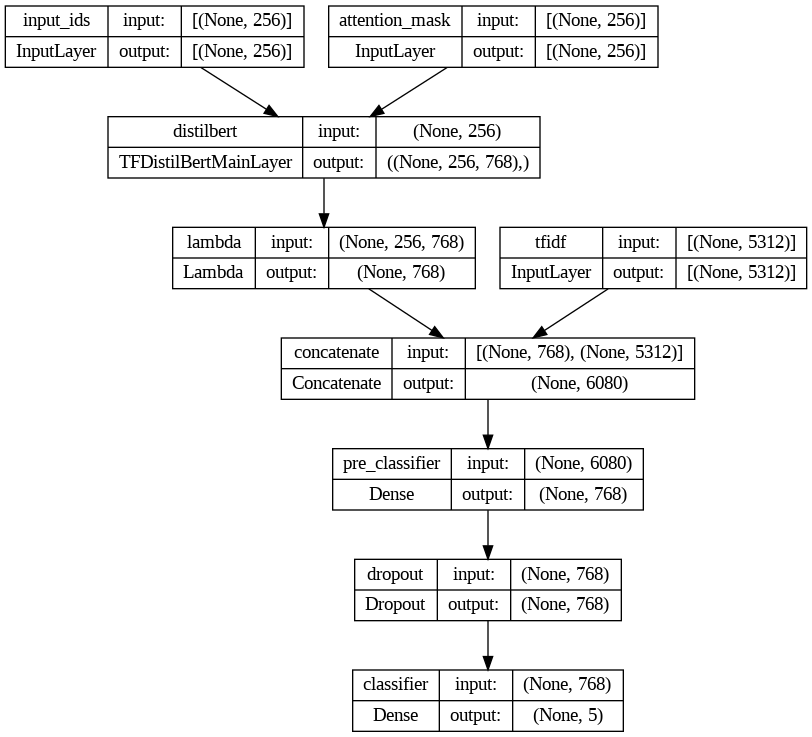


✓ Model TF-IDF input layer shape: [(None, 5312)]
✓ Data TF-IDF shape: (2764, 5312)
✓ Model built successfully!


In [ ]:

print("Building NEW model...")
print(f"Model will expect TF-IDF size: {cfg['number_of_additional_features']}")

input_ids, input_masks, input_tfidf, classifier = get_model_graph(cfg)
model = configure_model(input_ids, input_masks, input_tfidf, classifier)

model.summary()
model_image = tf.keras.utils.plot_model(model, show_shapes=True, show_layer_names=True)
display(model_image)

# Verify that the input layer has the correct size
tfidf_input_shape = model.get_layer('tfidf').output_shape
print(f"\n✓ Model TF-IDF input layer shape: {tfidf_input_shape}")
print(f"✓ Data TF-IDF shape: {train_inputs['tfidf'].shape}")

print('✓ Model built successfully!')

### Training

In [ ]:
# config
cfg['checkpoints_dir'] = 'checkpoints'  # directory where checkpoints will be saved when training the model
cfg['model_name'] = 'experimento6'  # identificador al guardar los checkpoints
cfg['trained_model_name'] = os.path.join(cfg['checkpoints_dir'], cfg['model_name'])

epochs_max = 3
epochs_to_save = 1 # if epochs_max % epochs_to_save !=0 extra iterations might occur
batch_size = 64

# fine-tunning
for epoch_current in range(0, epochs_max, epochs_to_save):
    epoch_from = epoch_current +1
    epoch_to = epoch_current + epochs_to_save
    print(f'Training model, epochs {epoch_from} - {epoch_to}')

    # train the model. Optionally, validation data can be supplied => validation_data=(val_inputs,val_blabels_t)
    model.fit(train_inputs, y=train_labels_t, initial_epoch=epoch_current, epochs=epoch_to, batch_size=batch_size, validation_data=(val_inputs,val_labels_t))

    model.save_weights(cfg['trained_model_name'], save_format="tf")

print('Done!')

Training model, epochs 1 - 1
44/44 [==============================] - 105s 2s/step - loss: 0.5588 - binary_accuracy: 0.7075 - val_loss: 0.4819 - val_binary_accuracy: 0.7443
Training model, epochs 2 - 2
Epoch 2/2
44/44 [==============================] - 75s 2s/step - loss: 0.4182 - binary_accuracy: 0.7952 - val_loss: 0.4189 - val_binary_accuracy: 0.8035
Training model, epochs 3 - 3
Epoch 3/3
44/44 [==============================] - 75s 2s/step - loss: 0.3103 - binary_accuracy: 0.8645 - val_loss: 0.4107 - val_binary_accuracy: 0.8122
Done!


### Evaluation

In [ ]:
dict_resultados = {}

In [ ]:

true_labels = train[class_col]

m_pred = predict_model(model, cfg, train[text_col].to_list(), pref='m')

dict_resultados['train'] = evaluate_model(true_labels, m_pred['labels_m'])  # notar que en este caso se no suministran los scores

print('Done!')

87/87 [==============================] - 29s 315ms/step
==== Sumario de la clasificación ==== 
              precision    recall  f1-score   support

         joy       0.96      0.68      0.79       674
     sadness       0.95      0.68      0.80       876
    surprise       0.94      0.85      0.89       839
        fear       0.92      0.92      0.92      1610
       anger       0.99      0.36      0.53       333

   micro avg       0.94      0.78      0.85      4332
   macro avg       0.95      0.70      0.79      4332
weighted avg       0.94      0.78      0.84      4332
 samples avg       0.80      0.73      0.75      4332

Label Acc  : 91.37%
F1 Macro   : 78.56%
Recall     : 69.74%
Precision  : 95.33%
Done!


In [ ]:
# predict on the validation data

true_labels = val[class_col]
m_pred = predict_model(model, cfg, val[text_col].to_list(), pref='m')
dict_resultados['val'] = evaluate_model(true_labels, m_pred['labels_m'])  # notar que en este caso se no suministran los scores

print('Done!')

4/4 [==============================] - 1s 299ms/step
==== Sumario de la clasificación ==== 
              precision    recall  f1-score   support

         joy       0.91      0.32      0.48        31
     sadness       0.94      0.50      0.65        34
    surprise       0.66      0.68      0.67        31
        fear       0.70      0.76      0.73        62
       anger       1.00      0.25      0.40        16

   micro avg       0.75      0.57      0.65       174
   macro avg       0.84      0.50      0.59       174
weighted avg       0.81      0.57      0.63       174
 samples avg       0.58      0.52      0.53       174

Label Acc  : 81.22%
F1 Macro   : 58.51%
Recall     : 50.16%
Precision  : 84.23%
Done!


In [ ]:
# configuraciones
cfg['stats_dir'] = 'stats'  # directory where evaluation results will be saved
cfg['model_name'] = 'experimento6'


os.makedirs(cfg['stats_dir'], exist_ok=True)


ruta = os.path.join(cfg['stats_dir'], f'{cfg["model_name"]}_results.json')

with open(ruta, "w", encoding="utf-8") as f:
    json.dump(dict_resultados, f, indent=4, ensure_ascii=False)

## Experiment 7: MultiHeadAttention + class_weight

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_transform.bias', 'vocab_projector.bias', 'vocab_transform.weight', 'vocab_layer_norm.bias', 'vocab_layer_norm.weight']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a Bert

Model: "distilbert-custom"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, 256)]                0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, 256)]                0         []                            
 )                                                                                                
                                                                                                  
 distilbert (TFDistilBertMa  ((None, 256, 768),           6636288   ['input_ids[0][0]',           
 inLayer)                    )                            0          'attention_mask[0][0]']      
                                                                                  

/usr/local/lib/python3.12/dist-packages/tf_keras/src/initializers/initializers.py:121: UserWarning: The initializer TruncatedNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


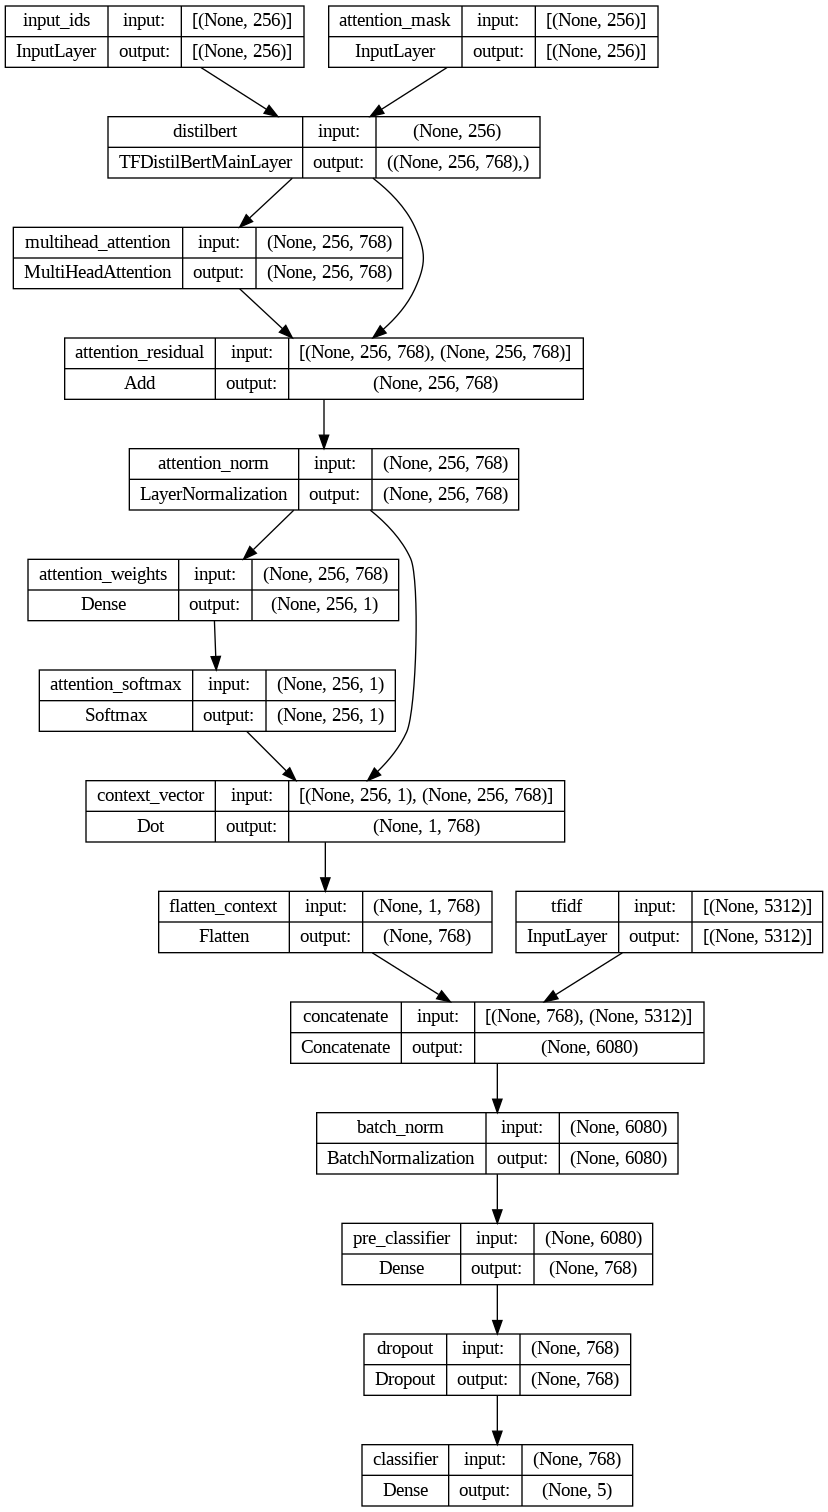

Done!


In [ ]:
# ==========================================================
# GENERAL CONFIGURATION
# ==========================================================

cfg = {}

cfg['framework'] = 'tf'
cfg['max_length'] = 256
cfg['transformer_model_name'] = 'distilbert-base-uncased'
cfg['num_labels'] = 5

# ==========================================================
# TOKENIZER
# ==========================================================

cfg['tokenizer'] = DistilBertTokenizer.from_pretrained(
    cfg['transformer_model_name']
)

# ==========================================================
# TF-IDF VECTORIZER
# ==========================================================

cfg['vectorizer'] = TfidfVectorizer(stop_words='english',max_features=10000)


cfg['vectorizer'].fit(train[text_col].to_list())


cfg['number_of_additional_features'] = len(
    cfg['vectorizer'].get_feature_names_out()
)


with open('vectorizer_reviews.pkl', 'wb') as f:
    pickle.dump(cfg['vectorizer'], f)

# ==========================================================
# LABEL BINARIZER
# ==========================================================

cfg['label_binarizer'] = preprocessing.MultiLabelBinarizer()


cfg['label_binarizer'].fit(train[class_col])


with open('label_binarizer_reviews.pkl', 'wb') as f:
    pickle.dump(cfg['label_binarizer'], f)

# ==========================================================
# MODELO
# ==========================================================

input_ids, input_masks, input_tfidf, classifier = get_model_graph_multiheadattention(cfg)

model = configure_model(input_ids,input_masks,input_tfidf,classifier)


model.summary()


model_image = tf.keras.utils.plot_model(model,show_shapes=True,show_layer_names=True)

display(model_image)

# ==========================================================
# LABELS
# ==========================================================


train_labels = train[emotions].values.astype('float32')
val_labels = val[emotions].values.astype('float32')


train_labels_t = tf.convert_to_tensor(train_labels)
val_labels_t = tf.convert_to_tensor(val_labels)

# ==========================================================
# INPUTS DEL MODELO
# ==========================================================

train_inputs = get_model_inputs(cfg,train[text_col].to_list())

val_inputs = get_model_inputs(cfg,val[text_col].to_list())

print('Done!')

In [ ]:

print("Preparing training data...")

# Prepare inputs
train_inputs = get_model_inputs(cfg, train[text_col].to_list())
val_inputs = get_model_inputs(cfg, val[text_col].to_list())

print(f"✓ Train TF-IDF shape: {train_inputs['tfidf'].shape}")
print(f"✓ Val TF-IDF shape: {val_inputs['tfidf'].shape}")

# Prepare labels
train_labels = train[emotions].values.astype('float32')
val_labels = val[emotions].values.astype('float32')

train_labels_t = tf.convert_to_tensor(train_labels)
val_labels_t = tf.convert_to_tensor(val_labels)

print(f"✓ Train labels shape: {train_labels.shape}")
print(f"✓ Val labels shape: {val_labels.shape}")


assert train_inputs['tfidf'].shape[1] == cfg['number_of_additional_features'], \
    f"Mismatch: model expects {cfg['number_of_additional_features']}, data has {train_inputs['tfidf'].shape[1]}"

print('✓ Data preparation complete!')

Preparing training data...
✓ Train TF-IDF shape: (2764, 5312)
✓ Val TF-IDF shape: (115, 5312)
✓ Train labels shape: (2764, 5)
✓ Val labels shape: (115, 5)
✓ Data preparation complete!


### Training

In [ ]:
# config
cfg['checkpoints_dir'] = 'checkpoints'
cfg['model_name'] = 'experimento7'
cfg['trained_model_name'] = os.path.join(cfg['checkpoints_dir'], cfg['model_name'])

epochs_max = 3
epochs_to_save = 1
batch_size = 32

print("Entrenando modelo con class weights...")
print(f"Epochs: {epochs_max}")
print(f"Batch size: {batch_size}")
print("-" * 60)

# fine-tunning
for epoch_current in range(0, epochs_max, epochs_to_save):
    epoch_from = epoch_current + 1
    epoch_to = epoch_current + epochs_to_save
    print(f'\nTraining model, epochs {epoch_from} - {epoch_to}')

    model.fit(
        train_inputs,
        y=train_labels_t,
        sample_weight=sample_weights_t,  # usar sample weights
        initial_epoch=epoch_current,
        epochs=epoch_to,
        batch_size=batch_size,
        validation_data=(val_inputs, val_labels_t)
    )

    # save checkpoint
    model.save_weights(cfg['trained_model_name'], save_format="tf")
    print(f" Checkpoint guardado: {cfg['trained_model_name']}")

print('\n✓ Training complete')

Entrenando modelo con class weights...
Epochs: 3
Batch size: 32
------------------------------------------------------------

Training model, epochs 1 - 1


/usr/local/lib/python3.12/dist-packages/tf_keras/src/backend.py:5820: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


87/87 [==============================] - 119s 1s/step - loss: 0.5814 - binary_accuracy: 0.6709 - val_loss: 0.5277 - val_binary_accuracy: 0.7461
 Checkpoint guardado: checkpoints/experimento7

Training model, epochs 2 - 2
Epoch 2/2
87/87 [==============================] - 86s 990ms/step - loss: 0.4101 - binary_accuracy: 0.7846 - val_loss: 0.4485 - val_binary_accuracy: 0.8070
 Checkpoint guardado: checkpoints/experimento7

Training model, epochs 3 - 3
Epoch 3/3
87/87 [==============================] - 86s 991ms/step - loss: 0.2990 - binary_accuracy: 0.8423 - val_loss: 0.6531 - val_binary_accuracy: 0.7009
 Checkpoint guardado: checkpoints/experimento7

✓ Entrenamiento completado


### Evaluation

In [ ]:
dict_resultados = {}

true_labels = train[class_col]

m_pred = predict_model(model, cfg, train[text_col].to_list(), pref='m')

dict_resultados['train'] = evaluate_model(true_labels, m_pred['labels_m'])  # notar que en este caso se no suministran los scores

print('Done!')

true_labels = val[class_col]
m_pred = predict_model(model, cfg, val[text_col].to_list(), pref='m')
dict_resultados['val'] = evaluate_model(true_labels, m_pred['labels_m'])  # notar que en este caso se no suministran los scores

print('Done!')

87/87 [==============================] - 31s 340ms/step
==== Sumario de la clasificación ==== 
              precision    recall  f1-score   support

         joy       0.92      0.67      0.78       674
     sadness       0.61      0.90      0.73       876
    surprise       0.47      0.99      0.63       839
        fear       0.83      0.93      0.87      1610
       anger       0.51      0.98      0.67       333

   micro avg       0.65      0.90      0.75      4332
   macro avg       0.67      0.90      0.74      4332
weighted avg       0.71      0.90      0.77      4332
 samples avg       0.64      0.81      0.69      4332

Label Acc  : 81.55%
F1 Macro   : 73.81%
Recall     : 89.52%
Precision  : 66.90%
Done!
4/4 [==============================] - 1s 283ms/step
==== Sumario de la clasificación ==== 
              precision    recall  f1-score   support

         joy       0.80      0.26      0.39        31
     sadness       0.53      0.91      0.67        34
    surprise       0.

## Experiment 8: MultiHeadAttention + FocalLoss

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_transform.bias', 'vocab_projector.bias', 'vocab_transform.weight', 'vocab_layer_norm.bias', 'vocab_layer_norm.weight']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a Bert

Model: "distilbert-custom"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, 128)]                0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, 128)]                0         []                            
 )                                                                                                
                                                                                                  
 distilbert (TFDistilBertMa  ((None, 128, 768),           6636288   ['input_ids[0][0]',           
 inLayer)                    )                            0          'attention_mask[0][0]']      
                                                                                  

/usr/local/lib/python3.12/dist-packages/tf_keras/src/initializers/initializers.py:121: UserWarning: The initializer TruncatedNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


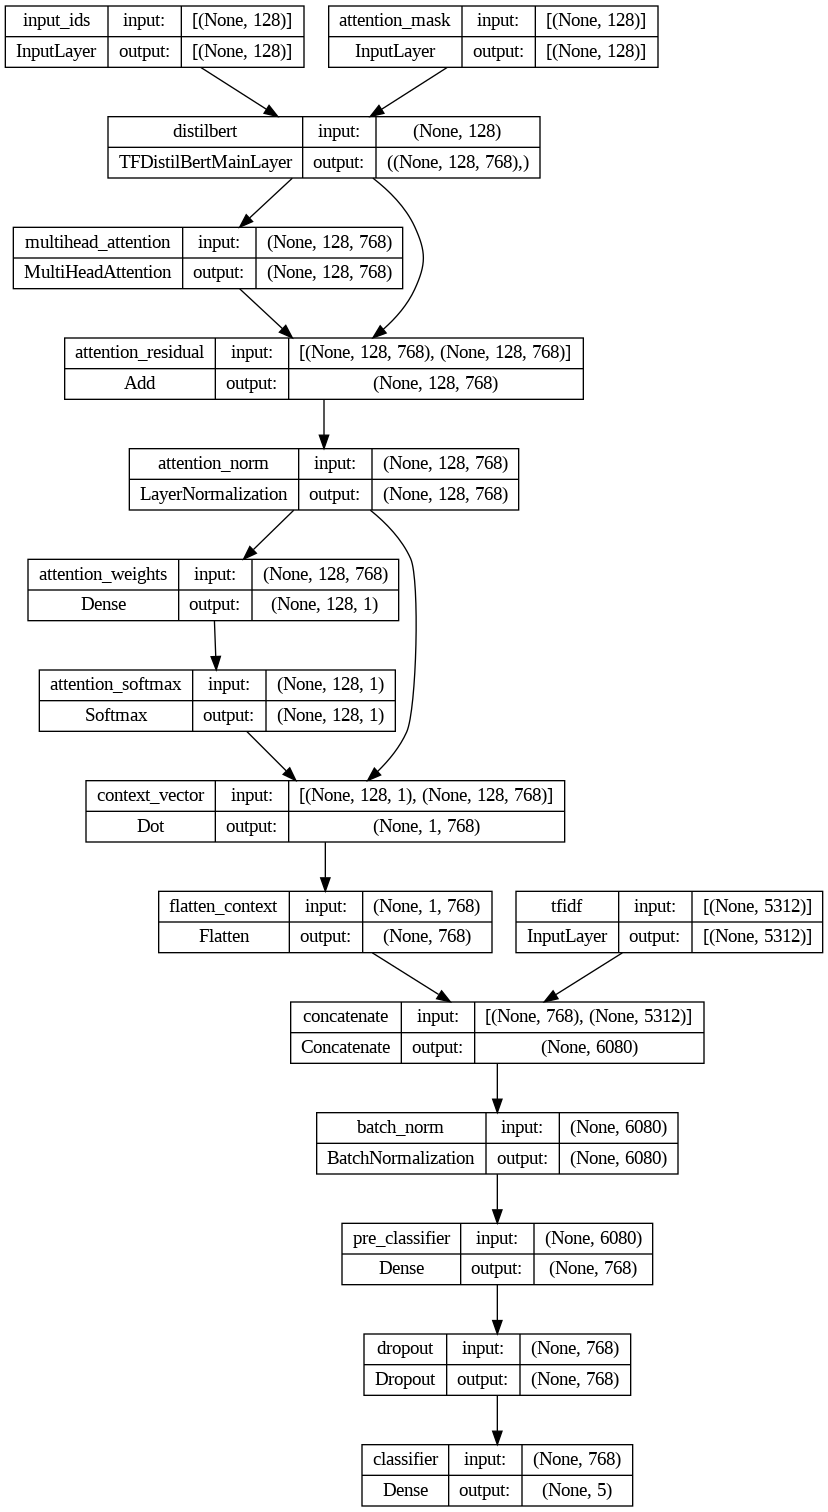

Done!


In [ ]:
# ==========================================================
# GENERAL CONFIGURATION
# ==========================================================

cfg = {}

cfg['framework'] = 'tf'
cfg['max_length'] = 128 # No puedo poner 256 creo que por limite de GPU
cfg['transformer_model_name'] = 'distilbert-base-uncased'
cfg['num_labels'] = 5

# ==========================================================
# TOKENIZER
# ==========================================================

cfg['tokenizer'] = DistilBertTokenizer.from_pretrained(
    cfg['transformer_model_name']
)

# ==========================================================
# TF-IDF VECTORIZER
# ==========================================================

cfg['vectorizer'] = TfidfVectorizer(stop_words='english',max_features=10000)

cfg['vectorizer'].fit(train[text_col].to_list())

cfg['number_of_additional_features'] = len(
    cfg['vectorizer'].get_feature_names_out()
)

with open('vectorizer_reviews.pkl', 'wb') as f:
    pickle.dump(cfg['vectorizer'], f)

# ==========================================================
# LABEL BINARIZER
# ==========================================================

cfg['label_binarizer'] = preprocessing.MultiLabelBinarizer()


cfg['label_binarizer'].fit(train[class_col])

with open('label_binarizer_reviews.pkl', 'wb') as f:
    pickle.dump(cfg['label_binarizer'], f)

# ==========================================================
# MODELO
# ==========================================================

input_ids, input_masks, input_tfidf, classifier = get_model_graph_multiheadattention(cfg)

model = configure_model_FL(input_ids,input_masks,input_tfidf,classifier)


model.summary()


model_image = tf.keras.utils.plot_model(model,show_shapes=True,show_layer_names=True)

display(model_image)

# ==========================================================
# LABELS
# ==========================================================


train_labels = train[emotions].values.astype('float32')
val_labels = val[emotions].values.astype('float32')


train_labels_t = tf.convert_to_tensor(train_labels)
val_labels_t = tf.convert_to_tensor(val_labels)

# ==========================================================
# INPUTS DEL MODELO
# ==========================================================

train_inputs = get_model_inputs(cfg,train[text_col].to_list())

val_inputs = get_model_inputs(cfg,val[text_col].to_list())

print('Done!')

### Training

In [ ]:
# config
cfg['checkpoints_dir'] = 'checkpoints'  # directory where checkpoints will be saved when training the model
cfg['model_name'] = 'experimento8'  # identificador al guardar los checkpoints
cfg['trained_model_name'] = os.path.join(cfg['checkpoints_dir'], cfg['model_name'])

epochs_max = 3
epochs_to_save = 1 # if epochs_max % epochs_to_save !=0 extra iterations might occur
batch_size = 64

# fine-tunning
for epoch_current in range(0, epochs_max, epochs_to_save):
    epoch_from = epoch_current +1
    epoch_to = epoch_current + epochs_to_save
    print(f'Training model, epochs {epoch_from} - {epoch_to}')

    # train the model. Optionally, validation data can be supplied => validation_data=(val_inputs,val_blabels_t)
    model.fit(train_inputs, y=train_labels_t, initial_epoch=epoch_current, epochs=epoch_to, batch_size=batch_size, validation_data=(val_inputs,val_labels_t))

    model.save_weights(cfg['trained_model_name'], save_format="tf")

print('Done!')

Training model, epochs 1 - 1


/usr/local/lib/python3.12/dist-packages/tf_keras/src/backend.py:5820: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


44/44 [==============================] - 85s 1s/step - loss: 0.1546 - binary_accuracy: 0.7200 - val_loss: 0.1132 - val_binary_accuracy: 0.7583
Training model, epochs 2 - 2
Epoch 2/2
44/44 [==============================] - 42s 948ms/step - loss: 0.0941 - binary_accuracy: 0.8200 - val_loss: 0.0978 - val_binary_accuracy: 0.7861
Training model, epochs 3 - 3
Epoch 3/3
44/44 [==============================] - 42s 949ms/step - loss: 0.0686 - binary_accuracy: 0.8768 - val_loss: 0.1002 - val_binary_accuracy: 0.8139
Done!


### Evaluation


In [ ]:
dict_resultados = {}

true_labels = train[class_col]

m_pred = predict_model(model, cfg, train[text_col].to_list(), pref='m',threshold = 0.5)
dict_resultados['train'] = evaluate_model(true_labels, m_pred['labels_m'])

print('Done!')
# predict on the validation data

true_labels = val[class_col]
m_pred = predict_model(model, cfg, val[text_col].to_list(), pref='m')
dict_resultados['val'] = evaluate_model(true_labels, m_pred['labels_m'])
print('Done!')

87/87 [==============================] - 16s 157ms/step
==== Sumario de la clasificación ==== 
              precision    recall  f1-score   support

         joy       0.98      0.60      0.75       674
     sadness       0.98      0.76      0.85       876
    surprise       0.93      0.75      0.83       839
        fear       0.95      0.89      0.92      1610
       anger       1.00      0.32      0.49       333

   micro avg       0.96      0.75      0.84      4332
   macro avg       0.97      0.67      0.77      4332
weighted avg       0.96      0.75      0.83      4332
 samples avg       0.77      0.70      0.72      4332

Label Acc  : 91.06%
F1 Macro   : 76.75%
Recall     : 66.51%
Precision  : 96.77%
Done!
4/4 [==============================] - 1s 143ms/step
==== Sumario de la clasificación ==== 
              precision    recall  f1-score   support

         joy       1.00      0.32      0.49        31
     sadness       0.83      0.59      0.69        34
    surprise       0.

# 📊 Model Comparison - Emotion Classification

---

## Experiment 1


### Metrics per Class

| Class    | Precision | Recall | F1-score | Support |
|----------|----------|--------|----------|---------|
| joy      | 0.91     | 0.32   | 0.48     | 31      |
| sadness  | 0.93     | 0.41   | 0.57     | 34      |
| surprise | 0.62     | 0.58   | 0.60     | 31      |
| fear     | 0.71     | 0.77   | 0.74     | 62      |
| anger    | 0.83     | 0.31   | 0.45     | 16      |

---

### Global Metrics

| Metric        | Precision | Recall | F1-score | Support |
|---------------|----------|--------|----------|---------|
| micro avg     | 0.74     | 0.55   | 0.63     | 174     |
| macro avg     | 0.80     | 0.48   | 0.57     | 174     |
| weighted avg  | 0.78     | 0.55   | 0.61     | 174     |
| samples avg   | 0.61     | 0.52   | 0.54     | 174     |

---

### Final Summary

- **Label Accuracy:** 80.35%
- **F1 Macro:** 56.81%
- **Recall:** 48.03%
- **Precision:** 80.05%



## Experiment 2

### Metrics per Class

| Class    | Precision | Recall | F1-score | Support |
|----------|----------|--------|----------|---------|
| joy      | 0.70     | 0.61   | 0.66     | 31      |
| sadness  | 0.67     | 0.76   | 0.71     | 34      |
| surprise | 0.80     | 0.52   | 0.63     | 31      |
| fear     | 0.68     | 0.71   | 0.69     | 62      |
| anger    | 0.78     | 0.44   | 0.56     | 16      |

### Global Metrics

| Metric        | Precision | Recall | F1-score | Support |
|---------------|----------|--------|----------|---------|
| micro avg     | 0.70     | 0.64   | 0.67     | 174     |
| macro avg     | 0.73     | 0.61   | 0.65     | 174     |
| weighted avg  | 0.71     | 0.64   | 0.67     | 174     |
| samples avg   | 0.62     | 0.60   | 0.59     | 174     |

**Label Acc:** 80.87%  
**F1 Macro:** 64.96%  
**Recall:** 60.82%  
**Precision:** 72.50%

---

##  Experiment 3

### Metrics per Class

| Class    | Precision | Recall | F1-score | Support |
|----------|----------|--------|----------|---------|
| joy      | 0.80     | 0.39   | 0.52     | 31      |
| sadness  | 1.00     | 0.26   | 0.42     | 34      |
| surprise | 0.84     | 0.52   | 0.64     | 31      |
| fear     | 0.84     | 0.52   | 0.64     | 62      |
| anger    | 0.78     | 0.44   | 0.56     | 16      |

### Global Metrics

| Metric        | Precision | Recall | F1-score | Support |
|---------------|----------|--------|----------|---------|
| micro avg     | 0.84     | 0.44   | 0.58     | 174     |
| macro avg     | 0.85     | 0.42   | 0.56     | 174     |
| weighted avg  | 0.86     | 0.44   | 0.57     | 174     |
| samples avg   | 0.55     | 0.42   | 0.46     | 174     |

---

##  Experiment 4

### Metrics per Class

| Class    | Precision | Recall | F1-score | Support |
|----------|----------|--------|----------|---------|
| joy      | 0.81     | 0.55   | 0.65     | 31      |
| sadness  | 0.77     | 0.71   | 0.74     | 34      |
| surprise | 0.57     | 0.68   | 0.62     | 31      |
| fear     | 0.85     | 0.56   | 0.68     | 62      |
| anger    | 0.61     | 0.88   | 0.72     | 16      |

### Global Metrics

| Metric        | Precision | Recall | F1-score | Support |
|---------------|----------|--------|----------|---------|
| micro avg     | 0.73     | 0.64   | 0.68     | 174     |
| macro avg     | 0.72     | 0.67   | 0.68     | 174     |
| weighted avg  | 0.76     | 0.64   | 0.68     | 174     |
| samples avg   | 0.63     | 0.58   | 0.58     | 174     |

**Label Acc:** 81.74%  
**F1 Macro:** 68.15%  
**Recall:** 67.42%  
**Precision:** 72.27%

---

##  Experiment 5

### Metrics per Class

| Class    | Precision | Recall | F1-score | Support |
|----------|----------|--------|----------|---------|
| joy      | 0.85     | 0.55   | 0.67     | 31      |
| sadness  | 0.92     | 0.65   | 0.76     | 34      |
| surprise | 0.72     | 0.58   | 0.64     | 31      |
| fear     | 0.77     | 0.74   | 0.75     | 62      |
| anger    | 0.83     | 0.31   | 0.45     | 16      |

### Global Metrics

| Metric        | Precision | Recall | F1-score | Support |
|---------------|----------|--------|----------|---------|
| micro avg     | 0.80     | 0.62   | 0.70     | 174     |
| macro avg     | 0.82     | 0.57   | 0.66     | 174     |
| weighted avg  | 0.81     | 0.62   | 0.69     | 174     |
| samples avg   | 0.68     | 0.59   | 0.61     | 174     |

**Label Acc:** 83.83%  
**F1 Macro:** 65.54%  
**Recall:** 56.61%  
**Precision:** 81.73%

---

## Experiment 6

### Metrics per Class

| Class    | Precision | Recall | F1-score | Support |
|----------|----------|--------|----------|---------|
| joy      | 0.84     | 0.52   | 0.64     | 31      |
| sadness  | 0.79     | 0.76   | 0.78     | 34      |
| surprise | 0.83     | 0.48   | 0.61     | 31      |
| fear     | 0.71     | 0.77   | 0.74     | 62      |
| anger    | 1.00     | 0.44   | 0.61     | 16      |

### Global Metrics

| Metric        | Precision | Recall | F1-score | Support |
|---------------|----------|--------|----------|---------|
| micro avg     | 0.77     | 0.64   | 0.70     | 174     |
| macro avg     | 0.83     | 0.60   | 0.68     | 174     |
| weighted avg  | 0.80     | 0.64   | 0.69     | 174     |
| samples avg   | 0.65     | 0.59   | 0.59     | 174     |

**Label Acc:** 83.48%  
**F1 Macro:** 67.51%  
**Recall:** 59.53%  
**Precision:** 83.38%

---

## Experiment 7

### Metrics per Class

| Class    | Precision | Recall | F1-score | Support |
|----------|----------|--------|----------|---------|
| joy      | 0.80     | 0.52   | 0.63     | 31      |
| sadness  | 0.57     | 0.82   | 0.67     | 34      |
| surprise | 0.54     | 0.90   | 0.67     | 31      |
| fear     | 0.61     | 0.95   | 0.74     | 62      |
| anger    | 0.64     | 0.44   | 0.52     | 16      |

### Global Metrics

| Metric        | Precision | Recall | F1-score | Support |
|---------------|----------|--------|----------|---------|
| micro avg     | 0.60     | 0.79   | 0.68     | 174     |
| macro avg     | 0.63     | 0.73   | 0.65     | 174     |
| weighted avg  | 0.63     | 0.79   | 0.68     | 174     |
| samples avg   | 0.62     | 0.72   | 0.63     | 174     |

**Label Acc:** 77.91%  
**F1 Macro:** 64.75%  
**Recall:** 72.64%  
**Precision:** 63.09%

---

##  Experiment 8

### Metrics per Class

| Class    | Precision | Recall | F1-score | Support |
|----------|----------|--------|----------|---------|
| joy      | 0.77     | 0.55   | 0.64     | 31      |
| sadness  | 0.91     | 0.29   | 0.44     | 34      |
| surprise | 0.73     | 0.35   | 0.48     | 31      |
| fear     | 0.82     | 0.52   | 0.63     | 62      |
| anger    | 1.00     | 0.31   | 0.48     | 16      |

### Global Metrics

| Metric        | Precision | Recall | F1-score | Support |
|---------------|----------|--------|----------|---------|
| micro avg     | 0.82     | 0.43   | 0.56     | 174     |
| macro avg     | 0.85     | 0.41   | 0.53     | 174     |
| weighted avg  | 0.83     | 0.43   | 0.56     | 174     |
| samples avg   | 0.54     | 0.41   | 0.45     | 174     |

**Label Acc:** 79.83%  
**F1 Macro:** 53.48%  
**Recall:** 40.52%  
**Precision:** 84.71%

# Conclusions

We can see that all these models are not good enough at generalizing the data compared to the training set, noticing a considerable drop in results when moving from train to test.

Of all our experiments, the one that best handles the task is experiment 4, adjusted with class_weight when F1 is the best measure, and experiment 6 incorporating a multi-head attention if we prioritize label accuracy with a score of 83.

Since the goal is to correctly identify emotions, I go with the one that has the highest F1, i.e., experiment 4 performed with balanced class_weights.

# Tkinter Interface

For the development of this work I proposed a tkinter interface a bit more sophisticated than the current one, which will be included in the following cell:

In [ ]:
# import tkinter as tk
# from tkinter import ttk

# path_base = os.getcwd()
# path_to_checkpoint = os.path.join(path_base, 'checkpoints')  # ruta al checkpoint del modelo entrenado

# # Nombre / Experimento
# models = {'Base':'checkpoints\\experimento1',
#         'modificacion':'checkpoints\\experimento2',
#         'With Attention':'checkpoints\\experimento3',
#         'MultiHeadAttention':'checkpoints\\experimento4'}  # nombres de los modelos disponibles
# print(f"Available models: {models}")

# # ==========================================================
# # GENERAL CONFIGURATION
# # ==========================================================

# cfg = {}

# text_col = 'text'
# class_col = emotions

# cfg['framework'] = 'tf'
# cfg['max_length'] = 512
# cfg['transformer_model_name'] = 'distilbert-base-uncased'
# cfg['num_labels'] = 5

# # ==========================================================
# # TOKENIZER
# # ==========================================================

# cfg['tokenizer'] = AutoTokenizer.from_pretrained(
#     cfg['transformer_model_name']
# )

# # ==========================================================
# # TF-IDF VECTORIZER
# # ==========================================================

# cfg['vectorizer'] = TfidfVectorizer(
#     stop_words='english',
#     max_features=10000
# )

# # entrenar vectorizador
# cfg['vectorizer'].fit(train[text_col].to_list())

# # cantidad de rasgos TF-IDF
# cfg['number_of_additional_features'] = len(
#     cfg['vectorizer'].get_feature_names_out()
# )

# # guardar vectorizador
# with open('vectorizer_reviews.pkl', 'wb') as f:
#     pickle.dump(cfg['vectorizer'], f)

# # ==========================================================
# # LABEL BINARIZER
# # ==========================================================

# cfg['label_binarizer'] = preprocessing.MultiLabelBinarizer()

# # entrenar label binarizer
# cfg['label_binarizer'].fit(train[class_col])


In [ ]:
# import tkinter as tk
# from tkinter import ttk
# import os

# test_list = test['text'].to_list()

# # =========================
# # MODELOS
# # =========================

# path_base = os.getcwd()
# path_to_checkpoint = os.path.join(path_base, 'checkpoints')  # ruta al checkpoint del modelo entrenado

# # Nombre / Experimento
# models = {'Base':'checkpoints\\experimento1',
#         'Base con Class Weights':'checkpoints\\experimento2',
#         'With Attention':'checkpoints\\experimento3',
#         'MultiHeadAttention':'checkpoints\\experimento4'}  # nombres de los modelos disponibles


# print(f"Available models: {models}")

# # =========================
# # PREDICTION FUNCTION
# # =========================

# def proponer_texto():
#     random_int = random.randint(0, len(test_list)-1)
#     text_input.delete("1.0", "end")
#     text_input.insert("1.0", test_list[random_int])


# def predict_emotion():
#     text = text_input.get("1.0", "end-1c")
#     if text.strip():

#         predictions = predict_model(model, cfg, [text], pref='m', threshold=0.5)
#         labels = predictions['labels_m'][0]

#         # === Pasar a probabilidades ===
#         emotion_cols = [c for c in predictions.columns if c.startswith("scores_m_")]

#         # logits
#         logits = predictions[emotion_cols].values

#         # Aplicar sigmoid para obtener probabilidades independientes
#         probs = 1 / (1 + np.exp(-logits))  # Sigmoid: σ(x) = 1/(1+e^(-x))

#         # Crear dataframe de probabilidades
#         df_probs = pd.DataFrame(probs, columns=emotion_cols)
#         df_probs.columns = df_probs.columns.str.replace("scores_m_", "", regex=False)

#         mostrar_resultados(labels, df_probs)
#     else:
#         emotion_label.config(text="Por favor ingresa un texto.")
#         for widget in prob_frame.winfo_children():
#             widget.destroy()


# def select_model(event):
#     model_name = selected_model.get()
#     path = models.get(model_name, None)


#     if model_name == "Base":
#         input_ids, input_masks, input_tfidf, classifier = get_model_graph(cfg)
#     elif model_name == 'Base con Class Weights':
#         input_ids, input_masks, input_tfidf, classifier = get_model_graph(cfg)
#     elif model_name == 'With Attention':
#         input_ids, input_masks, input_tfidf, classifier = get_model_graph_attention_mask(cfg)
#     elif model_name == 'MultiHeadAttention':
#         input_ids, input_masks, input_tfidf, classifier = get_model_graph_multiheadattention(cfg)

#     # ==== Instanciamos modelo =====
#     global model
#     model = configure_model(input_ids, input_masks, input_tfidf, classifier)
#     model.load_weights(path)

#     # ==== Ruta =====
#     experimento = path.split("\\")[-1]
#     summary_path = os.path.join('stats', f'{experimento}_results.json')

#     with open(summary_path, "r", encoding="utf-8") as f:
#         results = json.load(f)

#     df_train = pd.DataFrame(results["train"]).T
#     df_val = pd.DataFrame(results["val"]).T

#     drop_rows = ["micro avg", "macro avg", "weighted avg", "samples avg"]

#     df_train = df_train.drop(index=[r for r in drop_rows if r in df_train.index])
#     df_val = df_val.drop(index=[r for r in drop_rows if r in df_val.index])

#     text = f"{model_name}\n\n"
#     model_desc_label.config(text=text)

#     train_text.config(text=df_train.round(3).to_string())
#     val_text.config(text=df_val.round(3).to_string())

# # =========================
# # VENTANA PRINCIPAL
# # =========================

# root = tk.Tk()
# root.title("Emotion Analysis")
# root.geometry("900x500")
# root.configure(bg="#f0f0f0")

# # =========================
# # FRAME SUPERIOR
# # =========================

# top_frame = tk.Frame(
#     root,
#     bg="#f0f0f0"
# )
# top_frame.pack(
#     side="top",
#     fill="x",
#     padx=20,
#     pady=10
# )

# title_label = tk.Label(
#     top_frame,
#     text="Detector de Emociones",
#     font=("Arial", 22, "bold"),
#     bg="#f0f0f0",
#     fg="#333333"
# )
# title_label.pack(pady=10)

# selected_model = tk.StringVar()

# model_combo = ttk.Combobox(
#     top_frame,
#     textvariable=selected_model,
#     values=list(models.keys()),
#     state="readonly",
#     font=("Arial", 11),
#     width=30
# )

# model_combo.pack(pady=5)
# model_combo.set("Selecciona un modelo")
# model_combo.bind("<<ComboboxSelected>>", select_model)

# # =========================
# # FRAME PRINCIPAL
# # =========================

# main_frame = tk.Frame(
#     root,
#     bg="#f0f0f0"
# )
# main_frame.pack(
#     fill="both",
#     expand=True,
#     padx=20,
#     pady=10
# )

# # =========================
# # PANEL IZQUIERDO
# # =========================

# left_frame = tk.Frame(
#     main_frame,
#     bg="#ffffff",
#     relief="solid",
#     borderwidth=1
# )
# left_frame.pack(side="left", fill="both", expand=False, padx=10)

# label = tk.Label(
#     left_frame,
#     text="Ingresa tu texto:",
#     font=("Arial", 13, "bold"),
#     bg="#ffffff"
# )
# label.pack(
#     anchor="w",
#     padx=15,
#     pady=(15, 5)
# )

# text_input = tk.Text(
#     left_frame,
#     height=12,
#     font=("Arial", 11),
#     wrap="word",
#     relief="solid",
#     borderwidth=1
# )

# text_input.pack(
#     padx=15,
#     pady=10,
#     fill="both",
#     expand=True
# )

# buttons_frame = tk.Frame(left_frame, bg="#ffffff")
# buttons_frame.pack(padx=50, pady=10)


# analyze_button = tk.Button(
#     buttons_frame,
#     text="Analizar Emociones",
#     command=predict_emotion,
#     font=("Arial", 12, "bold"),
#     bg="#4CAF50",
#     fg="white",
#     activebackground="#45a049",
#     cursor="hand2",
#     padx=20,
#     pady=10,
#     relief="flat"
# )

# analyze_button.pack(
#     side = "left",
#     pady=15
# )

# propose_text_button = tk.Button(
#     buttons_frame,
#     text="Proponer Texto",
#     command=proponer_texto,
#     font=("Arial", 12, "bold"),
#     bg="#4C5BAF",
#     fg="white",
#     activebackground="#3B4A8C",
#     cursor="hand2",
#     padx=60,
#     pady=10,
#     relief="flat"
# )

# propose_text_button.pack(
#     side = "right",
#     padx=50,
# )

# # =========================
# # PANEL DERECHO
# # =========================

# right_frame = tk.Frame(
#     main_frame,
#     bg="#ffffff",
#     relief="solid",
#     borderwidth=1
# )
# right_frame.pack(
#     side="right",
#     fill="both",
#     expand=True,
#     padx=10
# )

# # =========================
# # PARTE SUPERIOR: RESULTADOS
# # =========================

# top_results_frame = tk.Frame(
#     right_frame,
#     bg="#ffffff"
# )
# top_results_frame.pack(
#     fill="both",
#     expand=True
# )

# results_title = tk.Label(
#     top_results_frame,
#     text="Resultados",
#     font=("Arial", 16, "bold"),
#     bg="#ffffff",
#     fg="#333333"
# )
# results_title.pack(pady=(20, 10))

# emotion_label = tk.Label(
#     top_results_frame,
#     text="",
#     font=("Arial", 24, "bold"),
#     bg="#ffffff"
# )
# emotion_label.pack(pady=10)

# prob_frame = tk.Frame(
#     top_results_frame,
#     bg="#ffffff"
# )
# prob_frame.pack(
#     fill="both",
#     expand=True,
#     padx=20,
#     pady=10
# )

# # =========================
# # SUMMARY
# # =========================

# bottom_summary_frame = tk.Frame(
#     right_frame,
#     bg="#f7f7f7",
#     relief="solid",
#     borderwidth=1,
#     height=280
# )
# bottom_summary_frame.pack(
#     fill="both",
#     expand=False,
#     padx=20,
#     pady=(10, 15)
# )

# bottom_summary_frame.pack_propagate(False)


# top_desc_frame = tk.Frame(
#     bottom_summary_frame,
#     bg="#f7f7f7"
# )
# top_desc_frame.pack(
#     fill="x",
#     pady=(5, 5)
# )

# model_desc_label = tk.Label(
#     top_desc_frame,
#     text="Model Description",
#     font=("Arial", 14, "bold"),
#     bg="#f7f7f7",
#     anchor="w",
#     justify="left"
# )
# model_desc_label.pack(
#     anchor="w",
#     padx=10
# )

# bottom_split = tk.Frame(
#     bottom_summary_frame,
#     bg="#f7f7f7"
# )
# bottom_split.pack(
#     fill="both",
#     expand=True,
#     padx=5,
#     pady=5
# )

# # LEFT: TRAIN
# train_frame = tk.Frame(
#     bottom_split,
#     bg="#ffffff",
#     relief="solid",
#     borderwidth=1
# )
# train_frame.pack(
#     side="left",
#     fill="both",
#     expand=True,
#     padx=(5, 5)
# )

# train_label = tk.Label(
#     train_frame,
#     text="TRAIN",
#     font=("Arial", 10, "bold"),
#     bg="#ffffff"
# )
# train_label.pack(anchor="w", padx=5, pady=5)

# train_text = tk.Label(
#     train_frame,
#     text="",
#     font=("Consolas", 10),
#     bg="#ffffff",
#     justify="left",
#     anchor="nw"
# )
# train_text.pack(fill="both", expand=True, padx=5, pady=5)

# # RIGHT: TEST / VAL
# val_frame = tk.Frame(
#     bottom_split,
#     bg="#ffffff",
#     relief="solid",
#     borderwidth=1
# )
# val_frame.pack(
#     side="right",
#     fill="both",
#     expand=True,
#     padx=(5, 5)
# )

# val_label = tk.Label(
#     val_frame,
#     text="VAL",
#     font=("Arial", 10, "bold"),
#     bg="#ffffff"
# )
# val_label.pack(anchor="w", padx=5, pady=5)

# val_text = tk.Label(
#     val_frame,
#     text="",
#     font=("Consolas", 10),
#     bg="#ffffff",
#     justify="left",
#     anchor="nw"
# )
# val_text.pack(fill="both", expand=True, padx=5, pady=5)

# def mostrar_resultados(label, probabilidades):
#     global prob_frame, top_results_frame
#     for widget in prob_frame.winfo_children():
#         widget.destroy()
#     for widget in top_results_frame.winfo_children():
#         widget.destroy()

#     emotion_colors = {
#         'joy': '#FFD700',
#         'sadness': '#1E90FF',
#         'anger': '#FF4500',
#         'fear': '#8A2BE2',
#         'surprise': '#FF8C00'
#     }

#     # =========================
#     # MAIN EMOTION
#     # =========================

#     emotion_label = tk.Label(
#         top_results_frame,
#         text="",
#         font=("Arial", 24, "bold"),
#         bg="#ffffff",
#         fg=emotion_colors.get(label, '#333333')
#     )

#     emotion_label.pack(pady=10)

#     prob_frame = tk.Frame(
#         top_results_frame,
#         bg="#ffffff"
#     )

#     prob_frame.pack(
#         fill="both",
#         expand=True,
#         padx=20,
#         pady=10
#     )

#     emotion_label.config(
#         text=label.upper(),
#         fg=emotion_colors.get(label, '#333333')
#     )

#     style = ttk.Style()

#     for emotion in probabilidades.columns:

#         color = emotion_colors.get(emotion, '#333333')

#         prob = float(probabilidades[emotion].iloc[0]) * 100

#         row_frame = tk.Frame(
#             prob_frame,
#             bg="#f0f0f0"
#         )
#         row_frame.pack(
#             fill="x",
#             pady=6
#         )

#         # =========================
#         # UNIQUE STYLE FOR EACH BAR
#         # =========================

#         style_name = f"{emotion}.Horizontal.TProgressbar"

#         style.configure(
#             style_name,
#             troughcolor="#dddddd",
#             background=color
#         )

#         # emotion name
#         emotion_text = tk.Label(
#             row_frame,
#             text=emotion.capitalize(),
#             font=("Arial", 11, "bold"),
#             width=12,
#             anchor="w",
#             bg="#f0f0f0",
#             fg=color
#         )
#         emotion_text.pack(side="left")


#         style = ttk.Style()
#         style.theme_use("clam")

#         style_name = f"{emotion}.Horizontal.TProgressbar"

#         style.configure(
#             style_name,
#             troughcolor="#dddddd",   # fondo barra
#             background=color,        # color progreso
#             lightcolor=color,
#             darkcolor=color,
#             bordercolor=color
#         )

#         # barra progreso
#         progress = ttk.Progressbar(
#             row_frame,
#             length=180,
#             maximum=100,
#             value=prob,
#             style=style_name
#         )

#         progress.pack(
#             side="left",
#             padx=5
#         )

#         # porcentaje
#         percent_label = tk.Label(
#             row_frame,
#             text=f"{prob:.1f}%",
#             font=("Arial", 10, "bold"),
#             bg="#f0f0f0",
#             fg=color
#         )

#         percent_label.pack(
#             side="left",
#             padx=5
#         )
# # =========================
# # LOOP
# # =========================
# root.mainloop()

This is commented out because this code does not work in Colab, but I share the code that produces the interface.


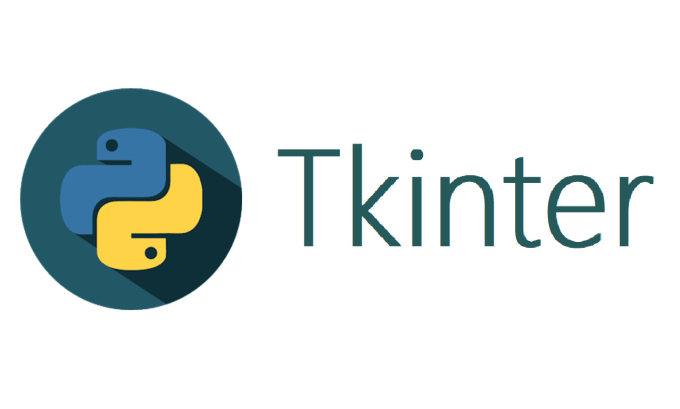

# Colab Interface

In [ ]:
import tkinter as tk
from tkinter import ttk

path_base = os.getcwd()
path_to_checkpoint = os.path.join(path_base, 'checkpoints')  # ruta al checkpoint del modelo entrenado

# Name / Experiment
models = {'Base':'checkpoints\\experimento1',
        'Sin TF-IDF':'checkpoints\\experimento2',
        'Focal Loss':'checkpoints\\experimento3',
        'Base con Class Weights':'checkpoints\\experimento4',
        'With Attention':'checkpoints\\experimento5',
        'MultiHeadAttention':'checkpoints\\experimento6',
        'MultiHeadAttention - CW':'checkpoints\\experimento7',
        'MultiHeadAttention - FL':'checkpoints\\experimento8'}  # nombres de los modelos disponibles
print(f"Available models: {models}")

lista_nombre_modelos = list(models.keys())

In [ ]:
# ==========================================================
# GENERAL CONFIGURATION
# ==========================================================

cfg = {}

text_col = 'text'
class_col = emotions

cfg['framework'] = 'tf'
cfg['max_length'] = 256
cfg['transformer_model_name'] = 'distilbert-base-uncased'
cfg['num_labels'] = 5

# ==========================================================
# TOKENIZER
# ==========================================================

cfg['tokenizer'] = DistilBertTokenizer.from_pretrained(
    cfg['transformer_model_name']
)

# ==========================================================
# TF-IDF VECTORIZER
# ==========================================================

cfg['vectorizer'] = TfidfVectorizer(
    stop_words='english',
    max_features=10000
)

# Train vectorizer
cfg['vectorizer'].fit(train[text_col].to_list())

# Number of TF-IDF features
cfg['number_of_additional_features'] = len(
    cfg['vectorizer'].get_feature_names_out()
)

# Save vectorizer
with open('vectorizer_reviews.pkl', 'wb') as f:
    pickle.dump(cfg['vectorizer'], f)

# ==========================================================
# LABEL BINARIZER
# ==========================================================

cfg['label_binarizer'] = preprocessing.MultiLabelBinarizer()

# Train label binarizer
cfg['label_binarizer'].fit(train[class_col])

In [ ]:
import gradio as gr

# =========================================================
# GLOBAL MODEL
# =========================================================
model = None

# =========================================================
# MODELS
# =========================================================
models = {
    'Base': 'checkpoints/experimento1',
    'Sin TF-IDF': 'checkpoints/experimento2',
    'Focal Loss': 'checkpoints/experimento3',
    'Base con Class Weights': 'checkpoints/experimento4',
    'With Attention': 'checkpoints/experimento5',
    'MultiHeadAttention': 'checkpoints/experimento6',
    'MultiHeadAttention - CW': 'checkpoints/experimento7',
    'MultiHeadAttention - FL': 'checkpoint/experimento8'
}  # available model names

model_names_list = list(models.keys())

# =========================================================
# LOAD MODEL
# =========================================================
import traceback

def load_model(model_name):
    global model

    try:
        print("Selected:", model_name)

        path = models.get(model_name)
        full_path = os.path.join(os.getcwd(), path)

        print("Final path:", full_path)

        if model_name == model_names_list[0]:  # Base
            input_ids, input_masks, input_tfidf, classifier = get_model_graph(cfg)
            model = configure_model(input_ids, input_masks, input_tfidf, classifier)

        elif model_name == model_names_list[1]:  # Without TF-IDF
            input_ids, input_masks, classifier = get_model_graph_sin_tfidf(cfg)
            model = configure_model_sin_tfidf(input_ids, input_masks, classifier)

        elif model_name == model_names_list[2]:  # FL
            input_ids, input_masks, input_tfidf, classifier = get_model_graph(cfg)
            model = configure_model_FL(input_ids, input_masks, input_tfidf, classifier)

        elif model_name == model_names_list[3]:  # With class weights
            input_ids, input_masks, input_tfidf, classifier = get_model_graph(cfg)
            model = configure_model(input_ids, input_masks, input_tfidf, classifier)

        elif model_name == model_names_list[4]:  # With attention
            input_ids, input_masks, input_tfidf, classifier = get_model_graph_attention_mask(cfg)
            model = configure_model(input_ids, input_masks, input_tfidf, classifier)

        elif model_name == model_names_list[5]:  # Multihead
            input_ids, input_masks, input_tfidf, classifier = get_model_graph_multiheadattention(cfg)
            model = configure_model(input_ids, input_masks, input_tfidf, classifier)

        elif model_name == model_names_list[6]:  # Multihead + CW
            input_ids, input_masks, input_tfidf, classifier = get_model_graph_multiheadattention(cfg)
            model = configure_model(input_ids, input_masks, input_tfidf, classifier)

        elif model_name == model_names_list[7]:  # Multihead + FL
            input_ids, input_masks, input_tfidf, classifier = get_model_graph_multiheadattention(cfg)
            model = configure_model_FL(input_ids, input_masks, input_tfidf, classifier)

        print("Model created successfully")

        print("Loading weights...")

        model.load_weights(full_path)

        print("Weights loaded successfully")

        return f"Loaded model: {model_name}"

    except Exception as e:
        print("MODEL LOADING ERROR:")
        traceback.print_exc()
        return f"ERROR: {str(e)}"


# =========================================================
# INFERENCE
# =========================================================
def infer(text):
    predictions = predict_model(model, cfg, [text], pref='m', threshold=0.5)
    labels = predictions['labels_m'][0]

    return labels


# =========================================================
# USER INTERFACE
# =========================================================
with gr.Blocks() as demo:

    gr.Markdown("# Classifier")

    model_dropdown = gr.Dropdown(
        choices=model_names_list,
        label="Select Model"
    )

    status = gr.Textbox(label="Model Status")

    input_text = gr.Textbox(label="Text")
    output_text = gr.Textbox(label="Output")

    # =====================================================
    # MODEL CHANGE EVENT
    # =====================================================
    model_dropdown.change(
        fn=load_model,
        inputs=model_dropdown,
        outputs=status
    )

    # =====================================================
    # INFERENCE
    # =====================================================
    input_text.submit(
        fn=infer,
        inputs=input_text,
        outputs=output_text
    )

demo.launch()

###

###